## Setup

This notebook was originally developed and trained on **Google Colab** with the dataset stored on Google Drive. The cell below has been adapted to run locally — point `DATA_PATH` at your local copy of the dataset.

> **Note:** The raw dataset (5M transactions) is not included in this repository due to its size. See the main [README](../README.md) for the dataset source.

In [ ]:
import os

DATA_PATH    = "./data/financial_fraud_detection_dataset.csv"
PLOTS_DIR    = "./outputs/plots"
MODELS_DIR   = "./outputs/trained_models"

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_SEED       = 36
UNDERSAMPLE_RATIO = 3

USE_GPU = True


Imports & Libraries

In [ ]:
!pip install pytorch-tabnet -q
print("pytorch-tabnet ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.2 MB/s eta 0:00:00
pytorch-tabnet ready


In [ ]:
import os
import gc
import json
import warnings
import joblib

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing           import LabelEncoder
from sklearn.impute                  import SimpleImputer
from sklearn.model_selection         import train_test_split
from sklearn.ensemble                import RandomForestClassifier
from sklearn.metrics                 import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
from xgboost  import XGBClassifier
import lightgbm as lgb
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

warnings.filterwarnings("ignore")

os.makedirs(PLOTS_DIR,  exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

_DEVICE_XGB = "cuda" if USE_GPU else "cpu"
_DEVICE_LGB = "gpu"  if USE_GPU else "cpu"
_DEVICE_TN  = "cuda" if (USE_GPU and torch.cuda.is_available()) else "cpu"

print("=" * 70)
print("  FRAUD DETECTION  (RF + XGBoost + LightGBM + TabNet)")
print("=" * 70)
print(f"  Data path        : {DATA_PATH}")
print(f"  Plots directory  : {PLOTS_DIR}/")
print(f"  Models directory : {MODELS_DIR}/")
print(f"  Undersample ratio: {UNDERSAMPLE_RATIO} : 1  (majority : minority)")
print(f"  GPU enabled      : {USE_GPU}")
print(f"  TabNet device    : {_DEVICE_TN}")
import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
print(f"random seed {RANDOM_SEED}")


  FRAUD DETECTION  (RF + XGBoost + LightGBM + TabNet)
  Data path        : /content/drive/MyDrive/Colab_Notebooks/financial_fraud_detection_dataset.csv
  Plots directory  : /content/drive/MyDrive/Colab_Notebooks/fraud_detection_plots_un3/
  Models directory : /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/
  Undersample ratio: 3 : 1  (majority : minority)
  GPU enabled      : True
  TabNet device    : cuda
random seed 36


 Load Data


In [ ]:
print("=" * 65)
print("Loading data")
print("=" * 65)

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape        : {df_raw.shape}")
print(f"Columns          : {df_raw.columns.tolist()}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")

# ─── Convert label to integer immediately ─────────────────────────────────────
df_raw["is_fraud"] = df_raw["is_fraud"].astype(int)

fraud_total = df_raw["is_fraud"].sum()
legit_total = len(df_raw) - fraud_total
print(f"\nFraud : {fraud_total:,}  ({fraud_total*100/len(df_raw):.2f}%)")
print(f"Legit : {legit_total:,}  ({legit_total*100/len(df_raw):.2f}%)")

Loading data
Raw shape        : (5000000, 18)
Columns          : ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash']

Missing values:
transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_chann

Exploratory Data Analysis (EDA)


Exploratory Data Analysis


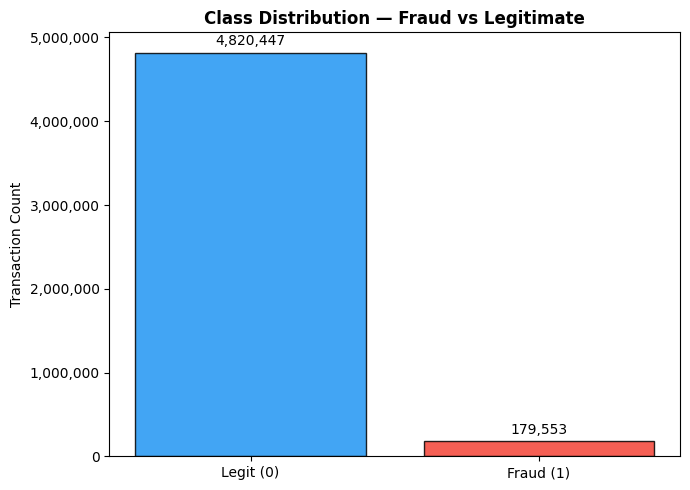

In [ ]:
print("\n" + "=" * 70)
print("Exploratory Data Analysis")
print("=" * 70)

fraud_count = df_raw["is_fraud"].sum()
legit_count = len(df_raw) - fraud_count


# ── 4.1  Class Distribution ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ["Legit (0)", "Fraud (1)"],
    [legit_total, fraud_total],
    color=["#2196F3", "#F44336"], edgecolor="black", alpha=0.85,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + legit_total * 0.01,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=10,
    )
ax.set_title("Class Distribution — Fraud vs Legitimate", fontweight="bold")
ax.set_ylabel("Transaction Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "01_class_distribution.png"), dpi=150)
plt.show()
# ── 4.2  Timestamp Parsing ─────────────────────────────────────────────────────
df_raw["timestamp"]   = pd.to_datetime(df_raw["timestamp"], errors="coerce")
df_raw["hour"]        = df_raw["timestamp"].dt.hour
df_raw["day"]         = df_raw["timestamp"].dt.day
df_raw["day_of_week"] = df_raw["timestamp"].dt.weekday
df_raw["month"]       = df_raw["timestamp"].dt.month


Fraud by Month:
       total_trans  fraud_trans  fraud_rate (%)
month                                          
7.0         424492        15395            3.63
12.0        424558        15376            3.62
10.0        424906        15331            3.61
9.0         411277        14855            3.61
2.0         382551        13777            3.60
6.0         410890        14759            3.59
4.0         411054        14761            3.59
3.0         425454        15247            3.58
11.0        411100        14730            3.58
8.0         425546        15208            3.57
5.0         423451        15133            3.57
1.0         424718        14981            3.53


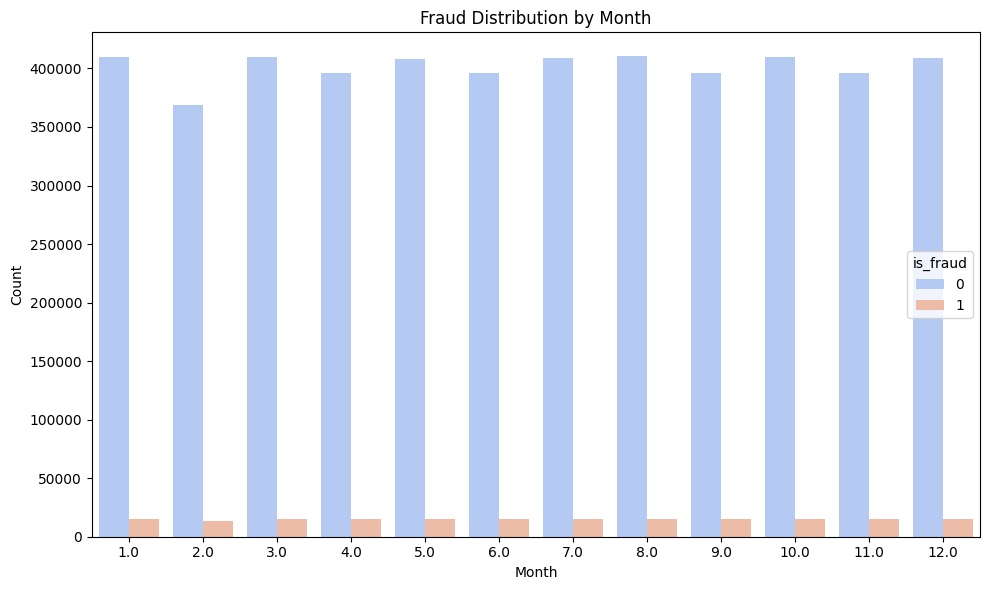

In [ ]:
# ── 4.3  Fraud by Month ────────────────────────────────────────────────────────
fraud_by_month = (
    df_raw.groupby("month")
      .agg(total_trans=("is_fraud", "count"), fraud_trans=("is_fraud", "sum"))
)
fraud_by_month["fraud_rate (%)"] = (
    fraud_by_month["fraud_trans"] * 100 / fraud_by_month["total_trans"]
).round(2)
print("\nFraud by Month:")
print(fraud_by_month.sort_values("fraud_rate (%)", ascending=False))

plt.figure(figsize=(10, 6))
sns.countplot(x="month", hue="is_fraud", data=df_raw, palette="coolwarm")
plt.title("Fraud Distribution by Month")
plt.xlabel("Month"); plt.ylabel("Count")
plt.legend(title="is_fraud", loc="center right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "02_fraud_by_month.png"), dpi=150)
plt.show()


Fraud by Transaction Type:
                  total_trans  fraud_trans  fraud_rate (%)
transaction_type                                          
transfer              1250334        45328            3.63
withdrawal            1248635        44874            3.59
deposit               1250593        44786            3.58
payment               1250438        44565            3.56


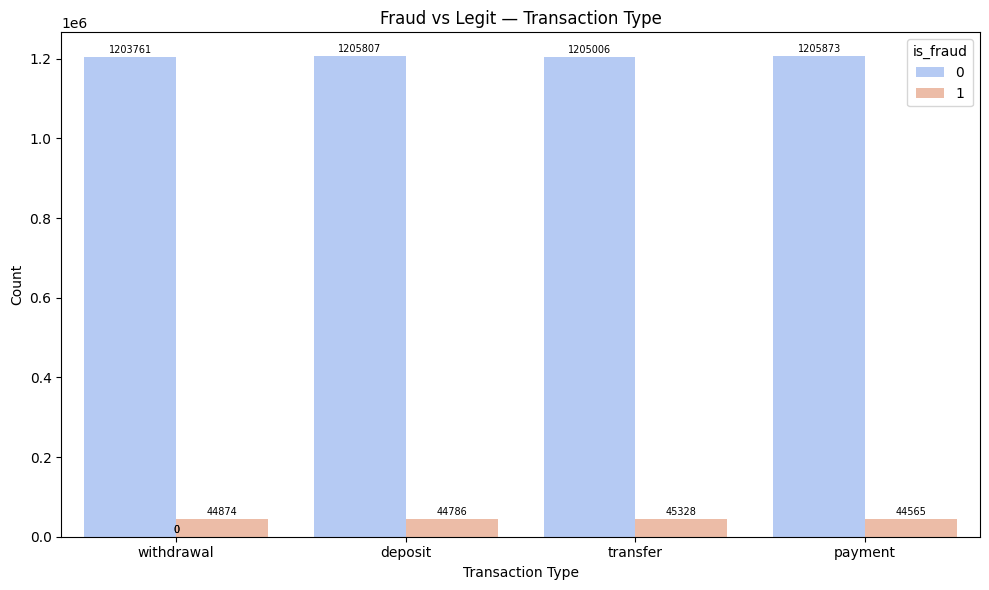

In [ ]:
# ── 4.4  Fraud by Transaction Type ────────────────────────────────────────────
fraud_by_tp = (
    df_raw.groupby("transaction_type")
      .agg(total_trans=("is_fraud", "count"), fraud_trans=("is_fraud", "sum"))
)
fraud_by_tp["fraud_rate (%)"] = (
    fraud_by_tp["fraud_trans"] * 100 / fraud_by_tp["total_trans"]
).round(2)
print("\nFraud by Transaction Type:")
print(fraud_by_tp.sort_values("fraud_rate (%)", ascending=False))

plt.figure(figsize=(10, 6))
ax = sns.countplot(x="transaction_type", hue="is_fraud", data=df_raw, palette="coolwarm")
plt.title("Fraud vs Legit — Transaction Type")
plt.xlabel("Transaction Type"); plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center", va="center", fontsize=7, xytext=(0, 5), textcoords="offset points",
    )
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "03_transaction_type.png"), dpi=150)
plt.show()


Fraud by Merchant Category:
                   total_trans  fraud_trans  fraud_rate (%)
merchant_category                                          
entertainment           625332        22573            3.61
other                   624589        22556            3.61
grocery                 624954        22516            3.60
travel                  625656        22503            3.60
online                  623581        22324            3.58
restaurant              625483        22367            3.58
retail                  626319        22453            3.58
utilities               624086        22261            3.57


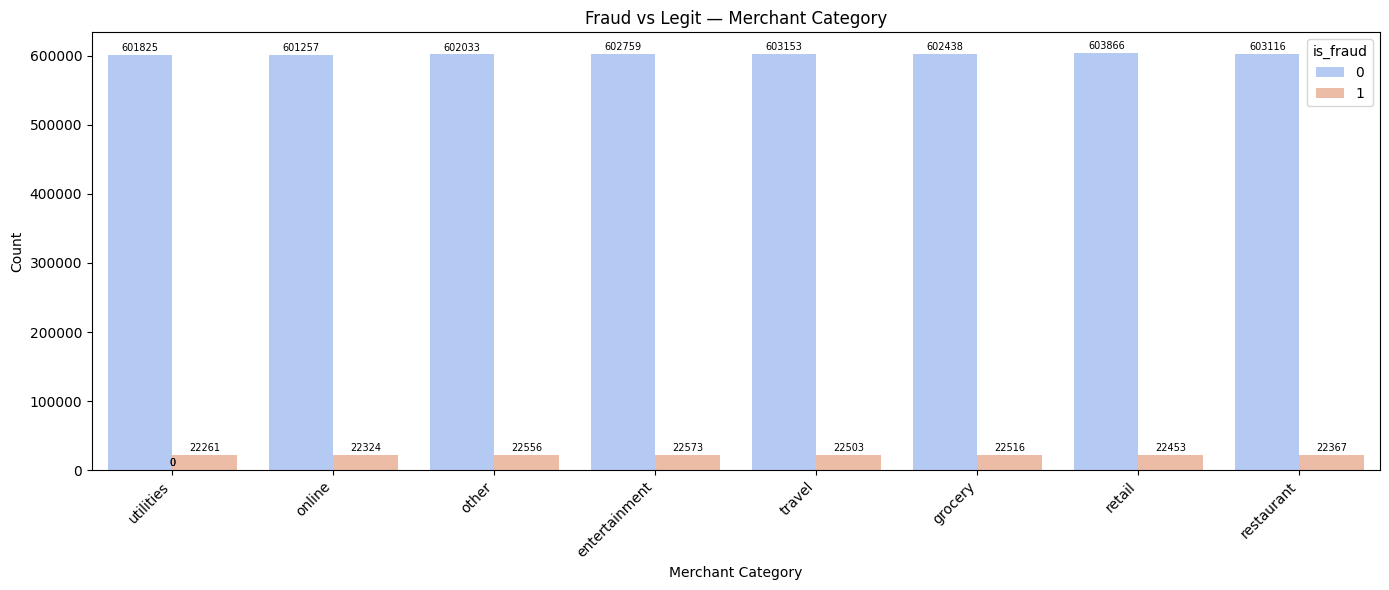

In [ ]:
# ── 4.5  Fraud by Merchant Category ───────────────────────────────────────────
fraud_by_mc = (
    df_raw.groupby("merchant_category")
      .agg(total_trans=("is_fraud", "count"), fraud_trans=("is_fraud", "sum"))
)
fraud_by_mc["fraud_rate (%)"] = (
    fraud_by_mc["fraud_trans"] * 100 / fraud_by_mc["total_trans"]
).round(2)
print("\nFraud by Merchant Category:")
print(fraud_by_mc.sort_values("fraud_rate (%)", ascending=False))

plt.figure(figsize=(14, 6))
ax = sns.countplot(x="merchant_category", hue="is_fraud", data=df_raw, palette="coolwarm")
plt.title("Fraud vs Legit — Merchant Category")
plt.xlabel("Merchant Category"); plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center", va="center", fontsize=7, xytext=(0, 5), textcoords="offset points",
    )
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "07_merchant_category.png"), dpi=150)
plt.show()

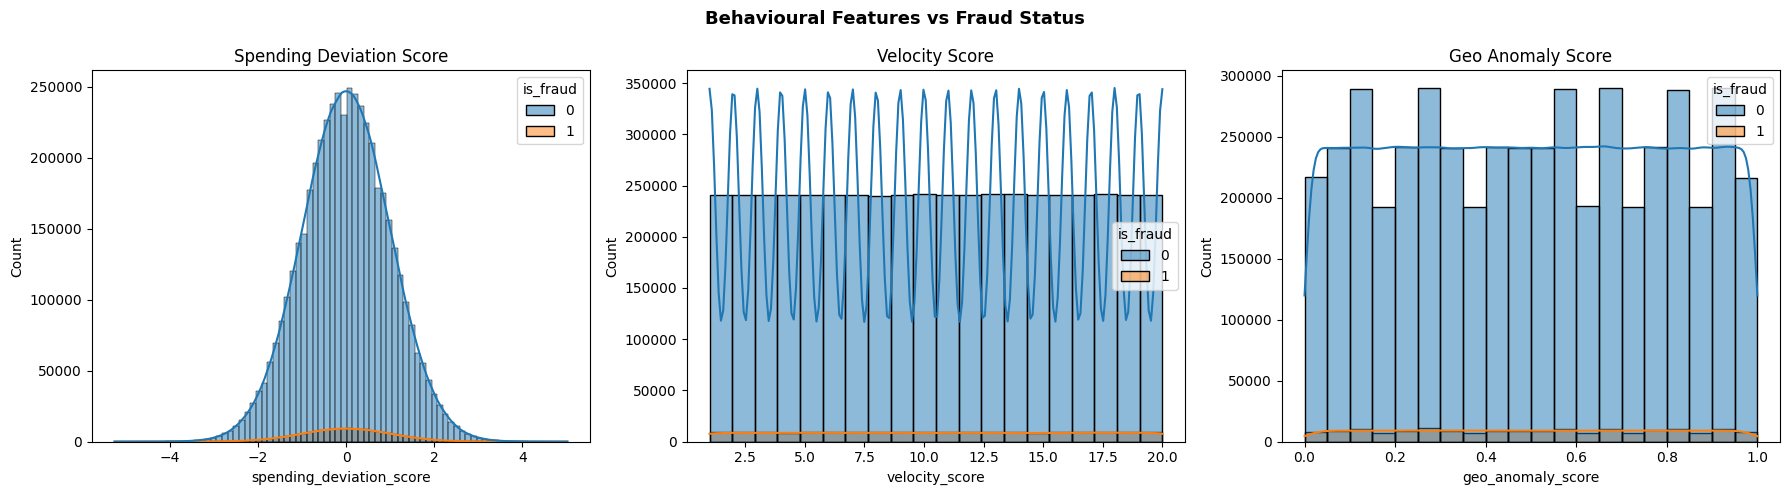

In [ ]:
# ── 4.6  Behavioral Feature Distributions ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df_raw, x="spending_deviation_score", hue="is_fraud",
             bins=80, kde=True, ax=axes[0])
axes[0].set_title("Spending Deviation Score")
sns.histplot(data=df_raw, x="velocity_score", hue="is_fraud",
             bins=20, kde=True, ax=axes[1])
axes[1].set_title("Velocity Score")
sns.histplot(data=df_raw, x="geo_anomaly_score", hue="is_fraud",
             bins=20, kde=True, ax=axes[2])
axes[2].set_title("Geo Anomaly Score")
plt.suptitle("Behavioural Features vs Fraud Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "04_behavioural_features.png"), dpi=150)
plt.show()

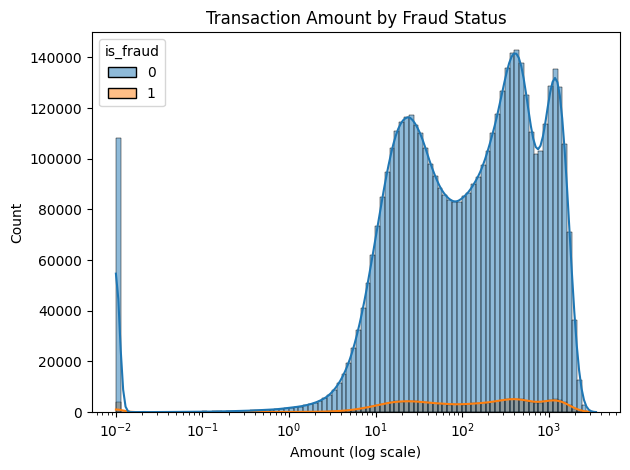

In [ ]:
# ── 4.7  Amount Distribution (log scale) ──────────────────────────────────────
sns.histplot(df_raw, x="amount", hue="is_fraud", bins=100, kde=True, log_scale=True)
plt.xlabel("Amount (log scale)")
plt.title("Transaction Amount by Fraud Status")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "05_amount_distribution.png"), dpi=150)
plt.show()


Fraud by Location:
           total_trans  fraud_trans  fraud_rate (%)
location                                           
London          624256        22478            3.60
Toronto         624349        22501            3.60
New York        625354        22460            3.59
Berlin          625289        22435            3.59
Sydney          625125        22458            3.59
Singapore       625313        22461            3.59
Dubai           624320        22340            3.58
Tokyo           625994        22420            3.58


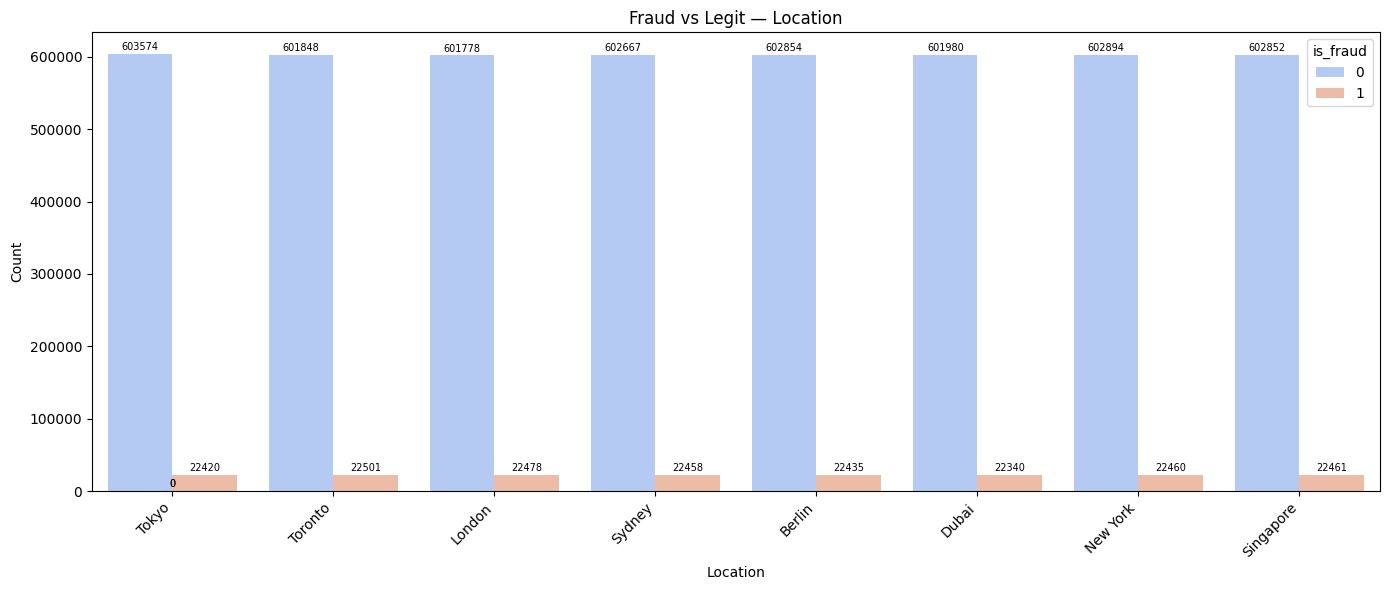


Fraud by Payment Channel:
                 total_trans  fraud_trans  fraud_rate (%)
payment_channel                                          
wire_transfer        1251219        45034            3.60
UPI                  1248847        44896            3.59
card                 1249693        44885            3.59
ACH                  1250241        44738            3.58


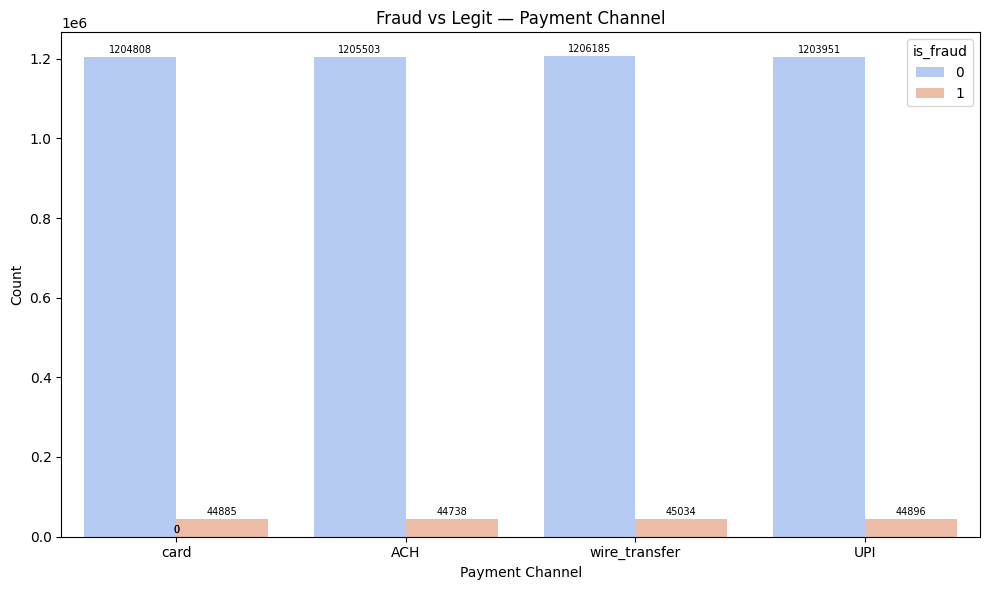

In [ ]:
# ── 4.8  Location & Payment Channel ───────────────────────────────────────────
fraud_by_loc = (
    df_raw.groupby("location")
      .agg(total_trans=("is_fraud", "count"), fraud_trans=("is_fraud", "sum"))
)
fraud_by_loc["fraud_rate (%)"] = (
    fraud_by_loc["fraud_trans"] * 100 / fraud_by_loc["total_trans"]
).round(2)
print("\nFraud by Location:")
print(fraud_by_loc.sort_values("fraud_rate (%)", ascending=False))

plt.figure(figsize=(14, 6))
ax = sns.countplot(x="location", hue="is_fraud", data=df_raw, palette="coolwarm")
plt.title("Fraud vs Legit — Location")
plt.xlabel("Location"); plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center", va="center", fontsize=7, xytext=(0, 5), textcoords="offset points",
    )
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "08_location.png"), dpi=150)
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
fraud_by_pc = (
    df_raw.groupby("payment_channel")
      .agg(total_trans=("is_fraud", "count"), fraud_trans=("is_fraud", "sum"))
)
fraud_by_pc["fraud_rate (%)"] = (
    fraud_by_pc["fraud_trans"] * 100 / fraud_by_pc["total_trans"]
).round(2)
print("\nFraud by Payment Channel:")
print(fraud_by_pc.sort_values("fraud_rate (%)", ascending=False))

plt.figure(figsize=(10, 6))
ax = sns.countplot(x="payment_channel", hue="is_fraud", data=df_raw, palette="coolwarm")
plt.title("Fraud vs Legit — Payment Channel")
plt.xlabel("Payment Channel"); plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center", va="center", fontsize=7, xytext=(0, 5), textcoords="offset points",
    )
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "09_payment_channel.png"), dpi=150)
plt.show()


Unique senders   : 896,513
Unique receivers : 896,639

Top 10 Senders by Fraud Count:
  sender_account  total_trans  fraud_trans  fraud_rate (%)
0      ACC367849           16            7           43.75
1      ACC312579            9            5           55.56
2      ACC651812           12            5           41.67
3      ACC649234           10            4           40.00
4      ACC800639            7            4           57.14
5      ACC894148           10            4           40.00
6      ACC933698           10            4           40.00
7      ACC319490           11            4           36.36
8      ACC936672            9            4           44.44
9      ACC560953            8            4           50.00


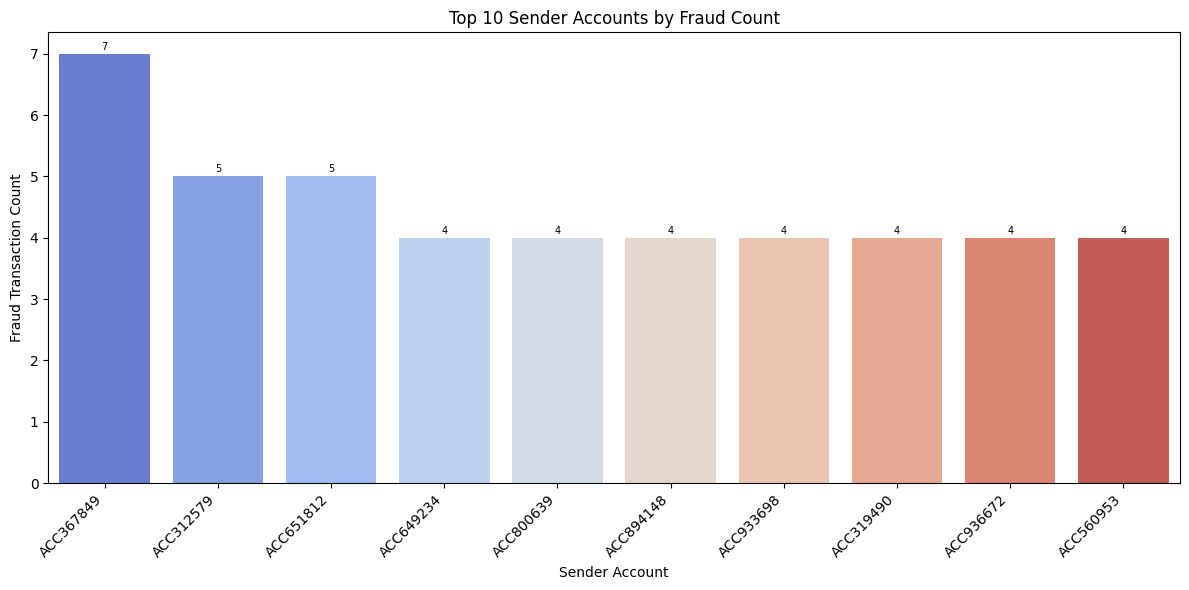


Top 10 Receivers by Fraud Count:
  receiver_account  total_trans  fraud_trans  fraud_rate (%)
0        ACC151819           12            5           41.67
1        ACC687510            4            4          100.00
2        ACC900245           10            4           40.00
3        ACC619289            9            4           44.44
4        ACC606029           10            4           40.00
5        ACC653076           10            4           40.00
6        ACC227324           11            4           36.36
7        ACC287154           11            4           36.36
8        ACC429565           11            4           36.36
9        ACC983163           10            4           40.00


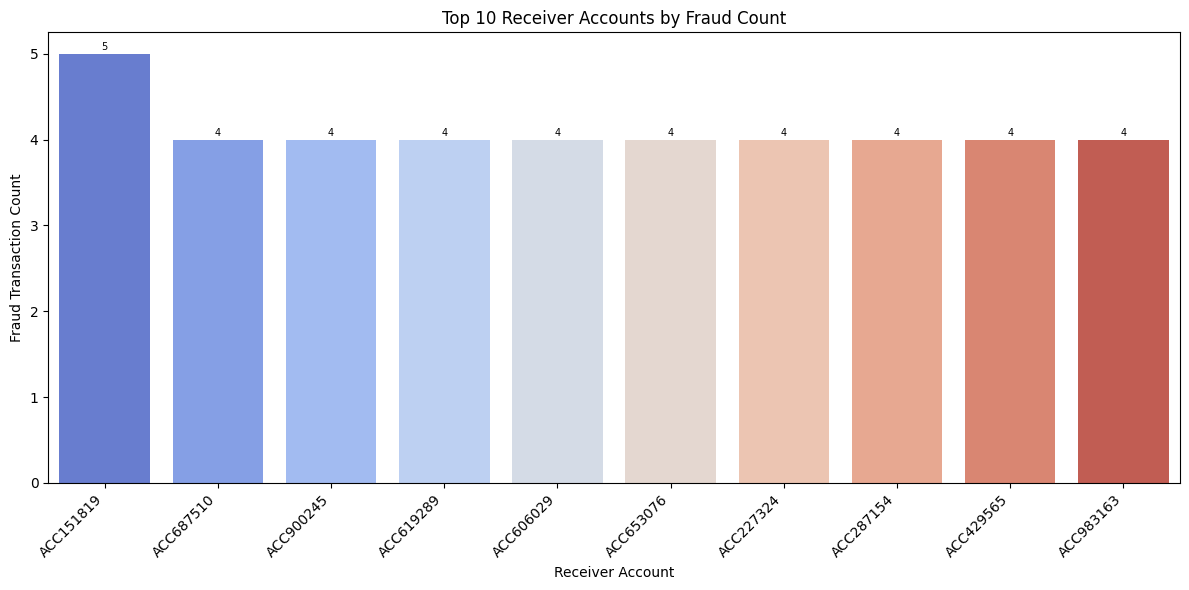

In [ ]:
# ── 4.9  Sender / Receiver Analysis ────────────────────────────────────────────
print(f"\nUnique senders   : {df_raw['sender_account'].nunique():,}")
print(f"Unique receivers : {df_raw['receiver_account'].nunique():,}")

# ── Sender accounts
fraud_by_sender = (
    df_raw.groupby("sender_account")
      .agg(total_trans=("is_fraud", "count"), fraud_trans=("is_fraud", "sum"))
)
fraud_by_sender["fraud_rate (%)"] = (
    fraud_by_sender["fraud_trans"] * 100 / fraud_by_sender["total_trans"]
).round(2)
top_senders = fraud_by_sender.sort_values("fraud_trans", ascending=False).head(10).reset_index()
print("\nTop 10 Senders by Fraud Count:")
print(top_senders)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="sender_account", y="fraud_trans", data=top_senders, palette="coolwarm")
plt.title("Top 10 Sender Accounts by Fraud Count")
plt.xlabel("Sender Account"); plt.ylabel("Fraud Transaction Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center", va="center", fontsize=7, xytext=(0, 5), textcoords="offset points",
    )
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "10a_top_senders_fraud.png"), dpi=150)
plt.show()

# ── Receiver accounts
fraud_by_receiver = (
    df_raw.groupby("receiver_account")
      .agg(total_trans=("is_fraud", "count"), fraud_trans=("is_fraud", "sum"))
)
fraud_by_receiver["fraud_rate (%)"] = (
    fraud_by_receiver["fraud_trans"] * 100 / fraud_by_receiver["total_trans"]
).round(2)
top_receivers = fraud_by_receiver.sort_values("fraud_trans", ascending=False).head(10).reset_index()
print("\nTop 10 Receivers by Fraud Count:")
print(top_receivers)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="receiver_account", y="fraud_trans", data=top_receivers, palette="coolwarm")
plt.title("Top 10 Receiver Accounts by Fraud Count")
plt.xlabel("Receiver Account"); plt.ylabel("Fraud Transaction Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center", va="center", fontsize=7, xytext=(0, 5), textcoords="offset points",
    )
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "10b_top_receivers_fraud.png"), dpi=150)
plt.show()

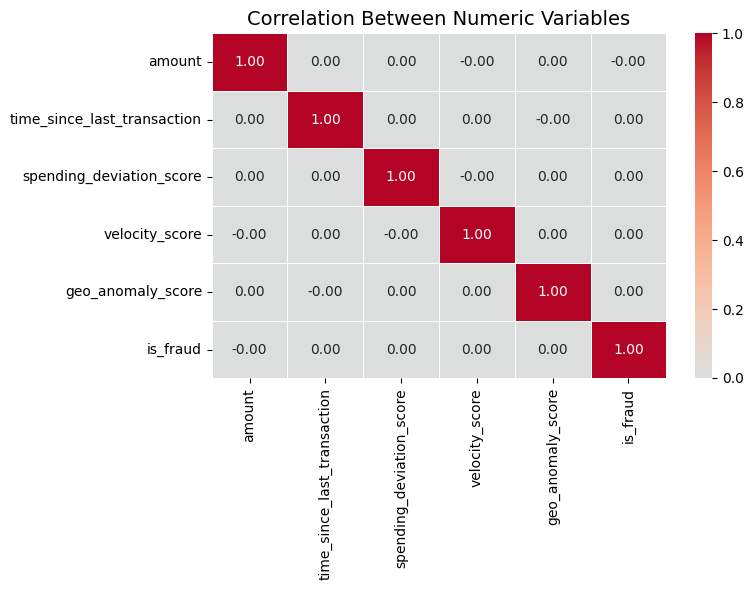


Statistical Summary:
             amount  time_since_last_transaction  spending_deviation_score  \
count  5.000000e+06                 4.103487e+06              5.000000e+06   
mean   3.589343e+02                 1.525799e+00             -3.881160e-04   
std    4.699333e+02                 3.576569e+03              1.000807e+00   
min    1.000000e-02                -8.777814e+03             -5.260000e+00   
25%    2.657000e+01                -2.562376e+03             -6.800000e-01   
50%    1.386700e+02                 8.442747e-01              0.000000e+00   
75%    5.038900e+02                 2.568339e+03              6.700000e-01   
max    3.520570e+03                 8.757758e+03              5.020000e+00   

       velocity_score  geo_anomaly_score  
count    5.000000e+06       5.000000e+06  
mean     1.050132e+01       5.000293e-01  
std      5.766842e+00       2.886349e-01  
min      1.000000e+00       0.000000e+00  
25%      5.000000e+00       2.500000e-01  
50%      1.100000

In [ ]:
# ── 4.10  Numerical Correlation Matrix ────────────────────────────────────────
corr_cols = [
    "amount", "time_since_last_transaction", "spending_deviation_score",
    "velocity_score", "geo_anomaly_score", "is_fraud",
]
corr_matrix = df_raw[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", center=0,
    linewidths=0.5, fmt=".2f",
)
plt.title("Correlation Between Numeric Variables", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "06_correlation_matrix_raw.png"), dpi=150)
plt.show()

print("\nStatistical Summary:")
print(df_raw[["amount", "time_since_last_transaction",
          "spending_deviation_score", "velocity_score",
          "geo_anomaly_score"]].describe())

Data Cleaning & Preprocessing

In [ ]:
print("\n" + "=" * 70)
print("Data Cleaning & Preprocessing")
print("=" * 70)

# ── 5.1  Sort chronologically per sender
df = df_raw.sort_values(["sender_account", "timestamp"]).reset_index(drop=True)

# ── 5.2  Drop non-predictive and target-leaking columns ───────────────────────
drop_early = ["transaction_id", "ip_address", "device_hash", "fraud_type"]
drop_early = [c for c in drop_early if c in df.columns]
df.drop(columns=drop_early, inplace=True)
print(f"Dropped (leakage / noise) : {drop_early}")
print(f"Shape after drop          : {df.shape}")

# ── 5.3  Impute missing numeric values
TSLT_SENTINEL = -99999.0

df["is_first_transaction"] = (
    df["time_since_last_transaction"].isnull().astype(np.int8)
)
df["time_since_last_transaction"] = (
    df["time_since_last_transaction"].fillna(TSLT_SENTINEL)
)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != "time_since_last_transaction"]
imputer  = SimpleImputer(strategy="mean")
df[num_cols] = imputer.fit_transform(df[num_cols])

print(f"Missing values remaining  : {df.isnull().sum().sum()}")
print(f"First-transaction flag    : {df['is_first_transaction'].sum():,} rows "
      f"({df['is_first_transaction'].mean()*100:.2f}%)")

# ── 5.4  Label-encode categorical columns
cat_cols    = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols    = [c for c in cat_cols if c not in ["timestamp", "sender_account",
                                                  "receiver_account"]]
label_encoders = {}

print(f"Encoding categorical columns : {cat_cols}")
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"Shape after encoding : {df.shape}")


Data Cleaning & Preprocessing
Dropped (leakage / noise) : ['transaction_id', 'ip_address', 'device_hash', 'fraud_type']
Shape after drop          : (5000000, 18)
Missing values remaining  : 3
Encoding categorical columns : ['transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel']
Shape after encoding : (5000000, 18)


Feature Engineering


Feature Engineering
Shape after feature engineering : (5000000, 40)
Memory after dtype optimisation : 1273 MB

  Saving Training Aggregates for Inference
  Sender lookup    → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/sender_lookup.parquet  (896,513 unique senders)
  Receiver lookup  → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/receiver_lookup.parquet  (896,639 unique receivers)
  Global fallback  → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/global_fallback.json
  Done. These files are required by inference_pipeline.py
Dropped identifiers : ['timestamp', 'sender_account', 'receiver_account']
Final shape         : (5000000, 37)

Top 20 features most correlated with is_fraud:
receiver_fraud_percentage     0.423180
sender_fraud_percentage       0.409992
receiver_fraud_transaction    0.384190
sender_fraud_transaction      0.378267
sender_total_transaction      0.017637
sender_degree                 0.017636
sender_std_amount             0.00316

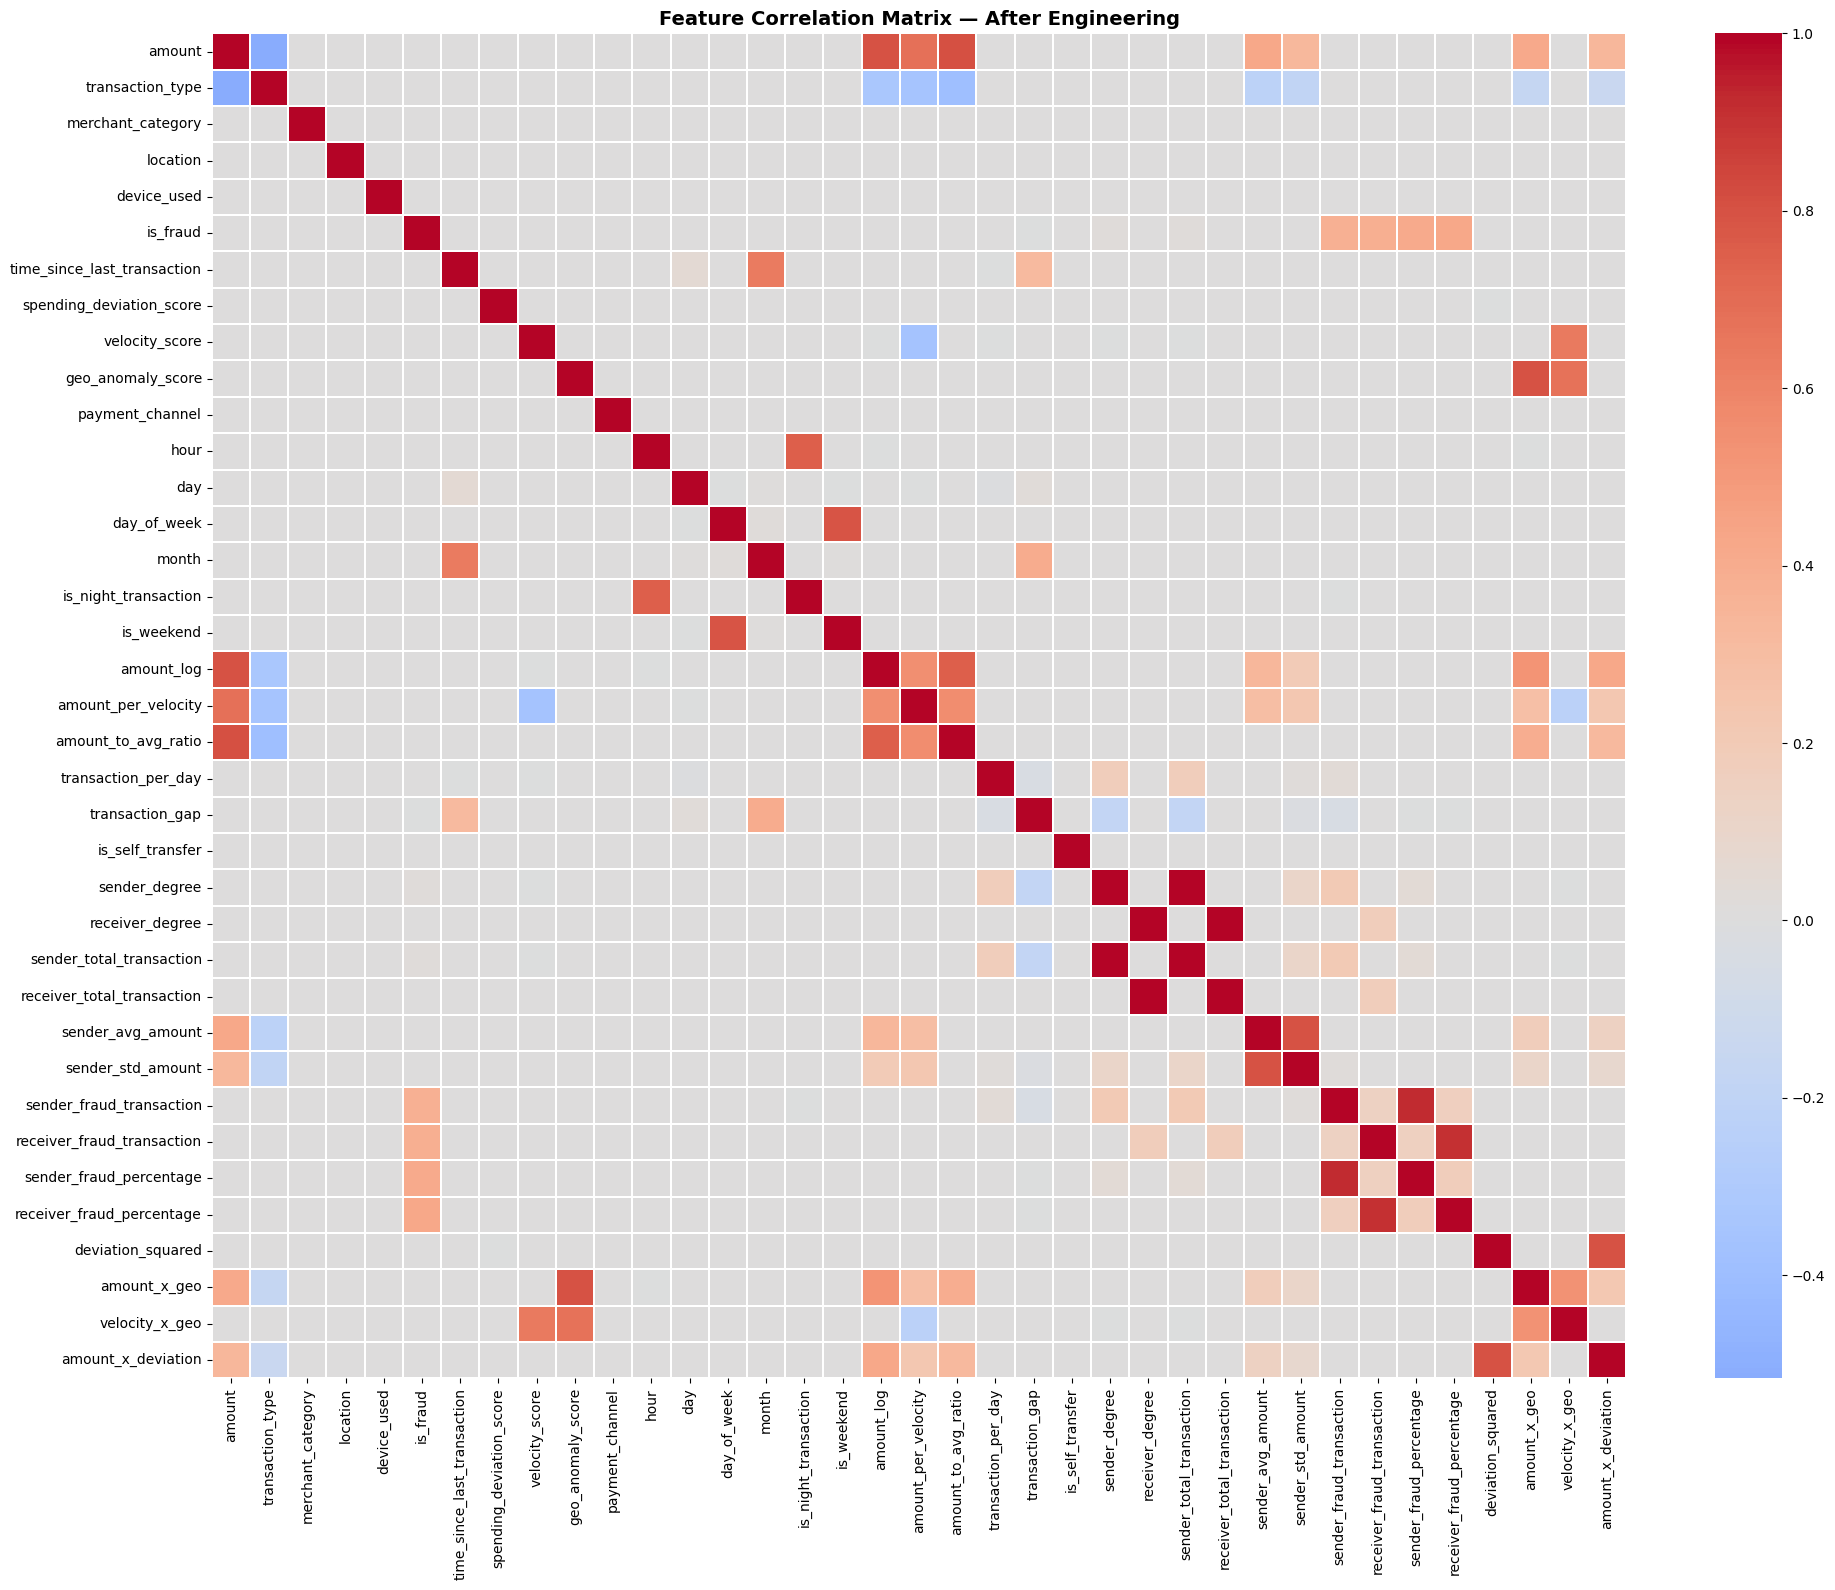

34229

In [ ]:
print("\n" + "=" * 70)
print("Feature Engineering")
print("=" * 70)

# ── ① Temporal risk flags ──────────────────────────────────────────────────────
df["is_night_transaction"] = df["hour"].between(18, 24).astype(np.int8)
df["is_weekend"]           = df["day_of_week"].isin([5, 6]).astype(np.int8)

# ── ② Amount / financial features ─────────────────────────────────────────────
df["amount_log"]          = np.log1p(df["amount"])
df["amount_per_velocity"] = df["amount"] / (df["velocity_score"] + 1)
df["amount_to_avg_ratio"] = (
    df["amount"] / df.groupby("sender_account")["amount"].transform("mean")
)
# ── ③ Frequency / velocity features ───────────────────────────────────────────
df["transaction_per_day"] = (
    df.groupby(["sender_account", "day"])["amount"].transform("count")
)
df["transaction_gap"] = (
    df.groupby("sender_account")["timestamp"]
      .diff()
      .dt.total_seconds()
      .fillna(0)
)

# ── ④ Risk / behavioural flags ─────────────────────────────────────────────────
df["is_self_transfer"] = (
    (df["sender_account"] == df["receiver_account"]).astype(np.int8)
)

# ── ⑤ Network / graph features — degree = number of unique counterparties ──────
df["sender_degree"]              = df.groupby("sender_account")["receiver_account"].transform("nunique")
df["receiver_degree"]            = df.groupby("receiver_account")["sender_account"].transform("nunique")
df["sender_total_transaction"]   = df.groupby("sender_account")["amount"].transform("count")
df["receiver_total_transaction"] = df.groupby("receiver_account")["amount"].transform("count")

# ── ⑥ Statistical aggregates per sender ───────────────────────────────────────
df["sender_avg_amount"] = df.groupby("sender_account")["amount"].transform("mean")
df["sender_std_amount"] = df.groupby("sender_account")["amount"].transform("std").fillna(0)

# ── ⑦ Fraud-history features ───────────────────────────────────────
df["sender_fraud_transaction"]   = df.groupby("sender_account")["is_fraud"].transform("sum")
df["receiver_fraud_transaction"] = df.groupby("receiver_account")["is_fraud"].transform("sum")
df["sender_fraud_percentage"]    = (
    df["sender_fraud_transaction"] * 100 / df["sender_total_transaction"]
).round(2).fillna(0)
df["receiver_fraud_percentage"]  = (
    df["receiver_fraud_transaction"] * 100 / df["receiver_total_transaction"]
).round(2).fillna(0)

# ── ⑧ Derived interaction / polynomial terms ──────────────────────────────────
df["deviation_squared"]  = df["spending_deviation_score"] ** 2
df["amount_x_geo"]       = df["amount_log"] * df["geo_anomaly_score"]
df["velocity_x_geo"]     = df["velocity_score"] * df["geo_anomaly_score"]
df["amount_x_deviation"] = df["amount_log"] * df["spending_deviation_score"].abs()

print(f"Shape after feature engineering : {df.shape}")

# ── Downcast dtypes to reduce memory footprint ─────────────────────────────────
for col in df.select_dtypes(include="float64").columns:
    df[col] = df[col].astype(np.float32)
for col in df.select_dtypes(include="int64").columns:
    df[col] = df[col].astype(np.int32)
df["is_fraud"] = df["is_fraud"].astype(int)   # keep target as standard int

mem_mb = df.memory_usage(deep=True).sum() / 1_048_576
print(f"Memory after dtype optimisation : {mem_mb:.0f} MB")
# ════════════════════════════════════════════════════════════════
# STEP — Save Training Aggregates for Inference
# Run once after feature engineering.
# This version is robust even if df already lost sender_account / receiver_account.
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  Saving Training Aggregates for Inference")
print("=" * 70)

import os
import json
import pandas as pd
import numpy as np

os.makedirs(MODELS_DIR, exist_ok=True)

# ---------------------------------------------------------------------
# 1) Re-load a source dataframe that still contains identifiers
# ---------------------------------------------------------------------
if "sender_account" in df.columns and "receiver_account" in df.columns:
    # In case you run this cell before dropping identifiers
    df_source = df.copy()
else:
    df_source = pd.read_csv(DATA_PATH)

if "is_fraud" in df_source.columns:
    df_source["is_fraud"] = df_source["is_fraud"].astype(int)
else:
    raise KeyError("Column 'is_fraud' not found in df_source.")

# Validate required identifier columns
required_id_cols = ["sender_account", "receiver_account", "amount", "is_fraud"]
missing_ids = [c for c in required_id_cols if c not in df_source.columns]
if missing_ids:
    raise KeyError(
        f"Missing required columns in source data: {missing_ids}. "
        "Make sure CLEAN_DATA_PATH points to the dataset before identifiers are dropped."
    )

# ---------------------------------------------------------------------
# 2) Build sender lookup
# ---------------------------------------------------------------------
sender_lookup = (
    df_source.groupby("sender_account", as_index=False)
    .agg(
        sender_avg_amount=("amount", "mean"),
        sender_std_amount=("amount", "std"),
        sender_degree=("receiver_account", "nunique"),
        sender_total_transaction=("amount", "count"),
        sender_fraud_transaction=("is_fraud", "sum"),
    )
)

sender_lookup["sender_std_amount"] = sender_lookup["sender_std_amount"].fillna(0)
sender_lookup["sender_fraud_percentage"] = (
    sender_lookup["sender_fraud_transaction"] * 100
    / sender_lookup["sender_total_transaction"]
).round(2).fillna(0)

sender_lookup = sender_lookup[
    [
        "sender_account",
        "sender_avg_amount",
        "sender_std_amount",
        "sender_degree",
        "sender_total_transaction",
        "sender_fraud_transaction",
        "sender_fraud_percentage",
    ]
].drop_duplicates(subset=["sender_account"])

sender_path = os.path.join(MODELS_DIR, "sender_lookup.parquet")
sender_lookup.to_parquet(sender_path, index=False)
print(f"  Sender lookup    → {sender_path}  ({len(sender_lookup):,} unique senders)")

# ---------------------------------------------------------------------
# 3) Build receiver lookup
# ---------------------------------------------------------------------
receiver_lookup = (
    df_source.groupby("receiver_account", as_index=False)
    .agg(
        receiver_degree=("sender_account", "nunique"),
        receiver_total_transaction=("amount", "count"),
        receiver_fraud_transaction=("is_fraud", "sum"),
    )
)

receiver_lookup["receiver_fraud_percentage"] = (
    receiver_lookup["receiver_fraud_transaction"] * 100
    / receiver_lookup["receiver_total_transaction"]
).round(2).fillna(0)

receiver_lookup = receiver_lookup[
    [
        "receiver_account",
        "receiver_degree",
        "receiver_total_transaction",
        "receiver_fraud_transaction",
        "receiver_fraud_percentage",
    ]
].drop_duplicates(subset=["receiver_account"])

receiver_path = os.path.join(MODELS_DIR, "receiver_lookup.parquet")
receiver_lookup.to_parquet(receiver_path, index=False)
print(f"  Receiver lookup  → {receiver_path}  ({len(receiver_lookup):,} unique receivers)")
# ---------------------------------------------------------------------
# 4) Global fallback values for unseen entities at inference time
#    Use current df if engineered columns exist, otherwise reasonable defaults.
# ---------------------------------------------------------------------
def safe_mean(frame, col, default=0.0):
    return float(frame[col].mean()) if col in frame.columns else float(default)

global_fallback = {
    "sender_avg_amount":          safe_mean(df, "sender_avg_amount", safe_mean(df_source, "amount", 0.0)),
    "sender_std_amount":          safe_mean(df, "sender_std_amount", 0.0),
    "sender_degree":              safe_mean(df, "sender_degree", 0.0),
    "sender_total_transaction":   safe_mean(df, "sender_total_transaction", 0.0),
    "sender_fraud_transaction":   0.0,
    "sender_fraud_percentage":    0.0,
    "receiver_degree":            safe_mean(df, "receiver_degree", 0.0),
    "receiver_total_transaction": safe_mean(df, "receiver_total_transaction", 0.0),
    "receiver_fraud_transaction": 0.0,
    "receiver_fraud_percentage":  0.0,
    "transaction_per_day":        safe_mean(df, "transaction_per_day", 0.0),
    "transaction_gap":            0.0,
    "amount_to_avg_ratio":        1.0,
}

fallback_path = os.path.join(MODELS_DIR, "global_fallback.json")
with open(fallback_path, "w") as f:
    json.dump(global_fallback, f, indent=2)

print(f"  Global fallback  → {fallback_path}")
print("  Done. These files are required by inference_pipeline.py")

# ── Drop identifier / datetime columns (no longer needed after FE) ─────────────
drop_final = ["timestamp", "sender_account", "receiver_account"]
drop_final = [c for c in drop_final if c in df.columns]
df.drop(columns=drop_final, inplace=True)
print(f"Dropped identifiers : {drop_final}")
print(f"Final shape         : {df.shape}")

# ── Post-engineering correlation heatmap ──────────────────────────────────────
corr_eng = df.corr()
is_fraud_corr = (
    corr_eng["is_fraud"].drop("is_fraud").sort_values(ascending=False)
)
print("\nTop 20 features most correlated with is_fraud:")
print(is_fraud_corr.head(20).to_string())

plt.figure(figsize=(20, 16))
sns.heatmap(corr_eng, annot=False, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature Correlation Matrix — After Engineering", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "07_correlation_matrix_engineered.png"), dpi=150)
plt.show()

gc.collect()

Stratified Split (80/10/10)

In [ ]:
print("\n" + "=" * 70)
print("  STEP A — Stratified Split (80/10/10) ")
print("=" * 70)

# ── Build X / y from the fully-engineered dataframe
y_full = df["is_fraud"]
X_full = df.drop(columns=["is_fraud"])

# Feature names = every column except the row-tracker
FEATURE_NAMES = X_full.columns.tolist()
N_FEATURES    = len(FEATURE_NAMES)

# ── Split 1: 80 % train_raw  |  20 % temp  (stratified → preserves ~4 % fraud) ─
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    X_full, y_full,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_full,
)

# ── Split 2: 50 % of temp → val  |  50 % of temp → test  ─────────────────────
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

del X_temp, y_temp, X_full, y_full
gc.collect()

print(f"  Train  (raw) : {X_train_raw.shape}  | fraud rate : {y_train_raw.mean():.4f}")
print(f"  Val          : {X_val.shape}         | fraud rate : {y_val.mean():.4f}")
print(f"  Test         : {X_test.shape}        | fraud rate : {y_test.mean():.4f}")
print(f"  Number of features : {N_FEATURES}")

# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  STEP B — Undersample TRAINING SET ONLY (2 : 1 majority : minority)")
print("=" * 70)
print("  Val & Test are left untouched — they reflect the real-world ratio.")

df_train = X_train_raw.copy()
df_train["is_fraud"] = y_train_raw.values

df_train_majority = df_train[df_train["is_fraud"] == 0]
df_train_minority = df_train[df_train["is_fraud"] == 1]

print(f"\n  Before undersampling:")
print(f"    Majority (legit) : {len(df_train_majority):,}")
print(f"    Minority (fraud) : {len(df_train_minority):,}")

df_train_majority_down = df_train_majority.sample(
    n=UNDERSAMPLE_RATIO * len(df_train_minority),
    random_state=RANDOM_SEED,
)
df_train_balanced = (
    pd.concat([df_train_majority_down, df_train_minority])
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

print(f"\n  After undersampling ({UNDERSAMPLE_RATIO}:1) — training only:")
print(f"    Total rows       : {len(df_train_balanced):,}")
print(f"    Fraud rate       : {df_train_balanced['is_fraud'].mean():.4f}")
print(f"    Class counts     : {df_train_balanced['is_fraud'].value_counts().to_dict()}")

del df_train, df_train_majority, df_train_minority, df_train_majority_down, X_train_raw, y_train_raw
gc.collect()



  STEP A — Stratified Split (80/10/10) 
  Train  (raw) : (4000000, 36)  | fraud rate : 0.0359
  Val          : (500000, 36)         | fraud rate : 0.0359
  Test         : (500000, 36)        | fraud rate : 0.0359
  Number of features : 36

  STEP B — Undersample TRAINING SET ONLY (2 : 1 majority : minority)
  Val & Test are left untouched — they reflect the real-world ratio.

  Before undersampling:
    Majority (legit) : 3,856,358
    Minority (fraud) : 143,642

  After undersampling (3:1) — training only:
    Total rows       : 574,568
    Fraud rate       : 0.2500
    Class counts     : {0: 430926, 1: 143642}


0

Prepare Final X / y Splits for Model Training

In [ ]:
print("\n" + "=" * 70)
print("  Finalising X / y splits for model training")
print("=" * 70)
X_train = df_train_balanced[FEATURE_NAMES]
y_train = df_train_balanced["is_fraud"]

X_val   = X_val[FEATURE_NAMES]
X_test  = X_test[FEATURE_NAMES]

del df_train_balanced, df
gc.collect()

print(f"  X_train : {X_train.shape}  | fraud rate : {y_train.mean():.4f}  (balanced for training)")
print(f"  X_val   : {X_val.shape}    | fraud rate : {y_val.mean():.4f}  (real-world ratio)")
print(f"  X_test  : {X_test.shape}   | fraud rate : {y_test.mean():.4f}  (real-world ratio)")
print(f"  Features: {N_FEATURES}")



  Finalising X / y splits for model training
  X_train : (574568, 36)  | fraud rate : 0.2500  (balanced for training)
  X_val   : (500000, 36)    | fraud rate : 0.0359  (real-world ratio)
  X_test  : (500000, 36)   | fraud rate : 0.0359  (real-world ratio)
  Features: 36


In [ ]:
results  = {}
pr_data  = {}
roc_data = {}
cm_data  = {}

MODEL_COLORS = {
    "Random Forest"    : "#2196F3",
    "XGBoost"          : "#FF5722",
    "LightGBM"         : "#9C27B0",
    "TabNet"           : "#00BCD4",
}


def find_optimal_threshold(y_true, y_proba, step=0.005):
    """
    Sweep classification thresholds on VALIDATION data.
    Returns the threshold that maximises binary F1-Score.

    Parameters
    ----------
    y_true  : ground-truth labels (validation set)
    y_proba : predicted fraud probabilities (validation set)
    step    : sweep granularity (default 0.005 = 0.5 pp)

    Returns
    -------
    best_thresh : float
    best_f1     : float
    """
    thresholds  = np.arange(0.05, 0.951, step)
    best_thresh = 0.5
    best_f1     = 0.0
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, preds, average="binary", zero_division=0
        )
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = round(float(t), 3)
    return best_thresh, round(best_f1, 4)


def evaluate_model(name, y_true, y_pred, y_proba, threshold=None):
    """Compute all metrics, print classification report, store in results dict."""
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred, average="binary", zero_division=0)
    rec     = recall_score(y_true, y_pred, average="binary", zero_division=0)
    f1      = f1_score(y_true, y_pred, average="binary", zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)
    ap      = average_precision_score(y_true, y_proba)
    thresh  = threshold if threshold is not None else 0.5

    print(f"\n{'='*66}")
    print(f"  MODEL     : {name}")
    print(f"  Threshold : {thresh:.3f}")
    print(f"{'='*66}")
    print(classification_report(
        y_true, y_pred,
        target_names=["Legit (0)", "Fraud (1)"],
        zero_division=0,
    ))
    print(f"  ROC-AUC            : {roc_auc:.4f}")
    print(f"  Avg Precision (AP) : {ap:.4f}")

    results[name] = {
        "Accuracy"   : round(acc,     4),
        "Precision"  : round(prec,    4),
        "Recall"     : round(rec,     4),
        "F1-Score"   : round(f1,      4),
        "ROC-AUC"    : round(roc_auc, 4),
        "AP (AUCPR)" : round(ap,      4),
        "Threshold"  : thresh,
    }


def plot_confusion_matrix(name, y_true, y_pred, cmap="Blues"):
    """Confusion matrix with absolute count + row-percentage annotation."""
    cm        = confusion_matrix(y_true, y_pred)
    cm_data[name] = {"cm": cm, "cmap": cmap}
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([
        [f"{v}\n({p:.1f}%)" for v, p in zip(rv, rp)]
        for rv, rp in zip(cm, cm_pct)
    ])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=labels, fmt="", cmap=cmap,
        xticklabels=["Legit", "Fraud"],
        yticklabels=["Legit", "Fraud"],
        ax=ax, linewidths=0.5, linecolor="gray",
        cbar_kws={"shrink": 0.8},
    )
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, f"cm_{name.replace(' ', '_')}.png"),
        dpi=150, bbox_inches="tight",
    )
    plt.show()


def plot_threshold_analysis(name, y_val_true, y_val_proba, best_thresh, color):
    """Two-panel plot: Precision & Recall vs threshold | F1 vs threshold."""
    thresholds = np.arange(0.05, 0.951, 0.005)
    precs, recs, f1s = [], [], []
    for t in thresholds:
        preds = (y_val_proba >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(
            y_val_true, preds, average="binary", zero_division=0
        )
        precs.append(p); recs.append(r); f1s.append(f)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(thresholds, precs, "--", color=color, label="Precision")
    axes[0].plot(thresholds, recs, "-", color="green", label="Recall")
    axes[0].axvline(best_thresh, color="red", linestyle=":", lw=2,
                    label=f"Optimal = {best_thresh:.3f}")
    axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
    axes[0].set_title(f"{name} — Precision & Recall vs. Threshold (Val)")
    axes[0].legend(loc="center left"); axes[0].grid(alpha=0.3)

    axes[1].plot(thresholds, f1s, color="#FF9800", lw=2, label="F1-Score")
    axes[1].axvline(best_thresh, color="red", linestyle=":", lw=2,
                    label=f"Optimal = {best_thresh:.3f}")
    axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("F1-Score")
    axes[1].set_title(f"{name} — F1-Score vs. Threshold (Val)")
    axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

    plt.suptitle(f"{name} — Threshold Optimisation", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, f"threshold_{name.replace(' ', '_')}.png"),
        dpi=150, bbox_inches="tight",
    )
    plt.show()


def plot_pr_curve(name, y_true, y_proba):
    """Individual Precision-Recall curve + storage for combined plot."""
    color                = MODEL_COLORS[name]
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap                   = average_precision_score(y_true, y_proba)
    pr_data[name]        = {"precision": precision, "recall": recall,
                             "ap": ap, "color": color}
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall, precision, color=color, lw=2, label=f"AP = {ap:.3f}")
    ax.set_xlabel("Recall", fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(f"Precision-Recall Curve — {name}", fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, f"pr_{name.replace(' ', '_')}.png"),
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print(f"  Average Precision (AP) : {ap:.4f}")


def plot_roc_curve(name, y_true, y_proba):
    """Individual ROC curve + storage for combined plot."""
    color          = MODEL_COLORS[name]
    fpr, tpr, _    = roc_curve(y_true, y_proba)
    auc_val        = roc_auc_score(y_true, y_proba)
    roc_data[name] = {"fpr": fpr, "tpr": tpr, "auc": auc_val, "color": color}
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc_val:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
    ax.set_title(f"ROC Curve — {name}", fontsize=12, fontweight="bold")
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, f"roc_{name.replace(' ', '_')}.png"),
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print(f"  ROC-AUC : {auc_val:.4f}")

Model Training

1 — Random Forest


  MODEL 1 — Random Forest
Training Random Forest ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   40.1s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  4.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


Training complete.



[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    7.1s finished


[ RF ]  Optimal threshold (val F1 = 0.7344) : 0.92


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.4s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    5.2s finished



  MODEL     : Random Forest
  Threshold : 0.920
              precision    recall  f1-score   support

   Legit (0)       1.00      0.98      0.99    482044
   Fraud (1)       0.60      0.95      0.74     17956

    accuracy                           0.98    500000
   macro avg       0.80      0.96      0.86    500000
weighted avg       0.98      0.98      0.98    500000

  ROC-AUC            : 0.9915
  Avg Precision (AP) : 0.7456


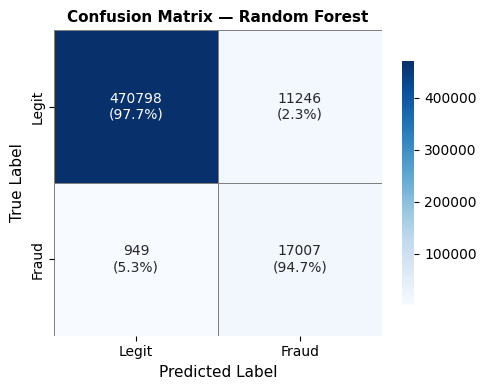

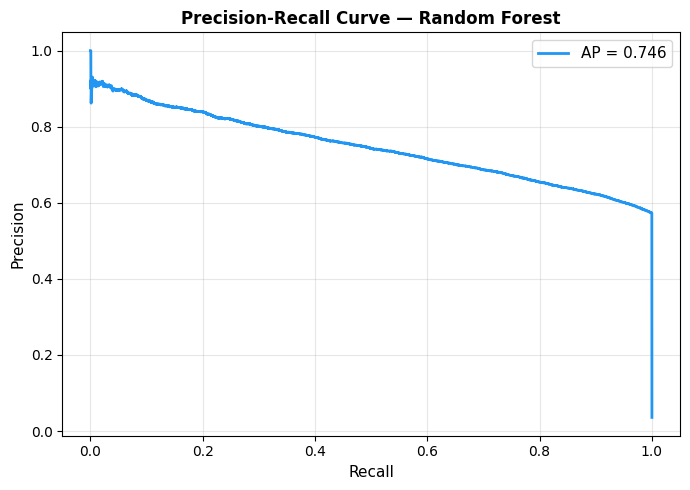

  Average Precision (AP) : 0.7456


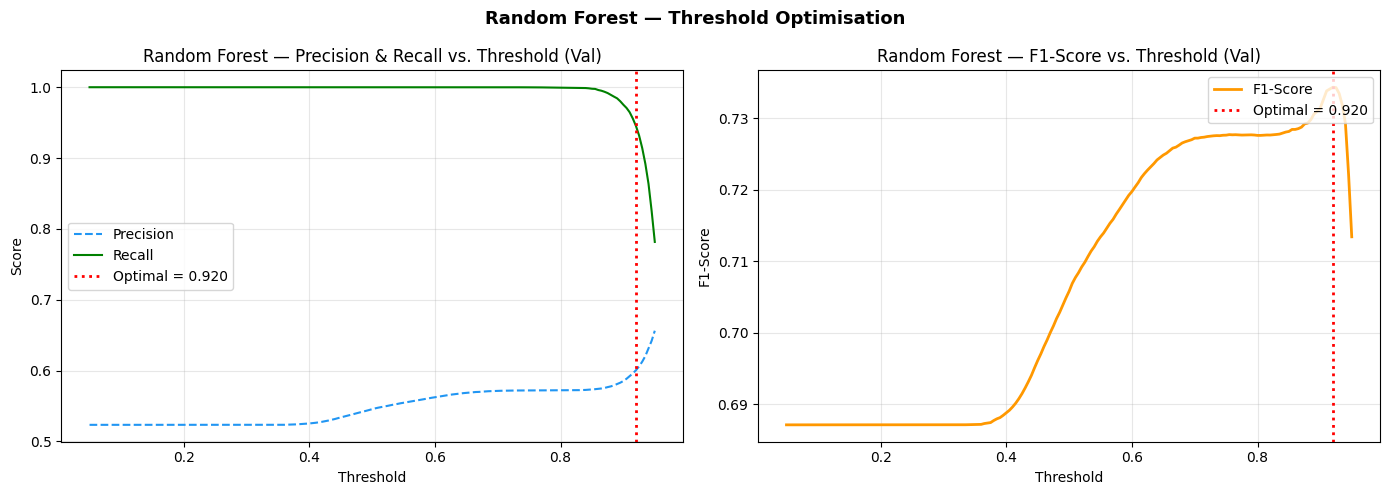

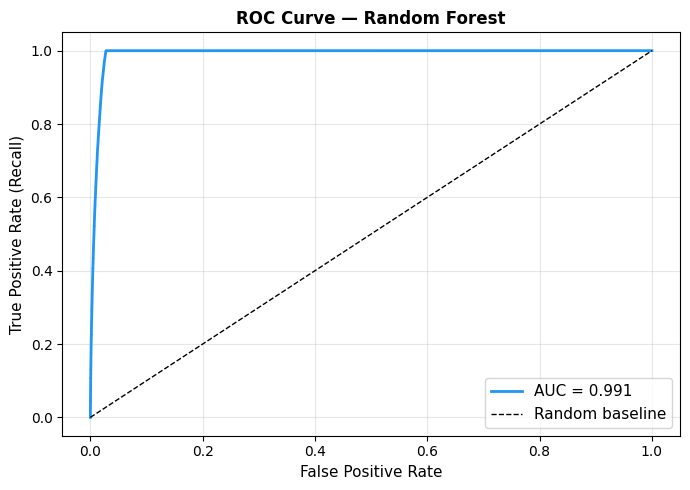

  ROC-AUC : 0.9915


In [ ]:
print("\n" + "=" * 70)
print("  MODEL 1 — Random Forest")
print("=" * 70)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_split=25,
    min_samples_leaf=10,
    max_features="sqrt",
    max_samples=0.6,
    bootstrap=True,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=1,
)
print("Training Random Forest ...")
rf_model.fit(X_train, y_train)
print("Training complete.\n")

y_proba_rf_val             = rf_model.predict_proba(X_val)[:, 1]
best_thresh_rf, best_f1_rf = find_optimal_threshold(y_val, y_proba_rf_val)
print(f"[ RF ]  Optimal threshold (val F1 = {best_f1_rf:.4f}) : {best_thresh_rf}")

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf  = (y_proba_rf >= best_thresh_rf).astype(int)

evaluate_model("Random Forest",    y_test, y_pred_rf,  y_proba_rf,      best_thresh_rf)
plot_confusion_matrix("Random Forest",    y_test, y_pred_rf,  cmap="Blues")
plot_pr_curve("Random Forest",    y_test, y_proba_rf)
plot_threshold_analysis(
    "Random Forest", y_val, y_proba_rf_val, best_thresh_rf, color="#2196F3"
)
plot_roc_curve("Random Forest",    y_test, y_proba_rf)

2 - XGBoost


  MODEL 2 — XGBoost
Training XGBoost ...
[0]	validation_0-aucpr:0.62297
[70]	validation_0-aucpr:0.75487
[140]	validation_0-aucpr:0.75837
[210]	validation_0-aucpr:0.76128
[280]	validation_0-aucpr:0.76166
[350]	validation_0-aucpr:0.76190
[420]	validation_0-aucpr:0.76206
[490]	validation_0-aucpr:0.76181
[560]	validation_0-aucpr:0.76149
[630]	validation_0-aucpr:0.76085
[699]	validation_0-aucpr:0.76004
Training complete.

[ XGB ] Optimal threshold (val F1 = 0.7359) : 0.935

  MODEL     : XGBoost
  Threshold : 0.935
              precision    recall  f1-score   support

   Legit (0)       1.00      0.98      0.99    482044
   Fraud (1)       0.61      0.94      0.74     17956

    accuracy                           0.98    500000
   macro avg       0.80      0.96      0.86    500000
weighted avg       0.98      0.98      0.98    500000

  ROC-AUC            : 0.9918
  Avg Precision (AP) : 0.7667


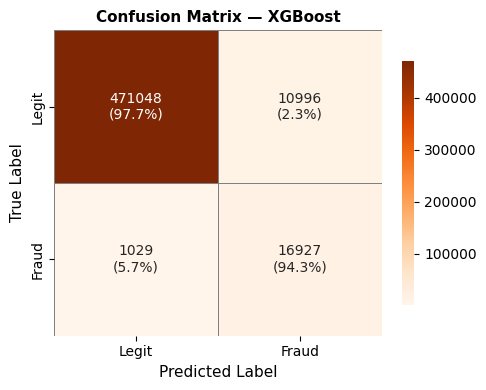

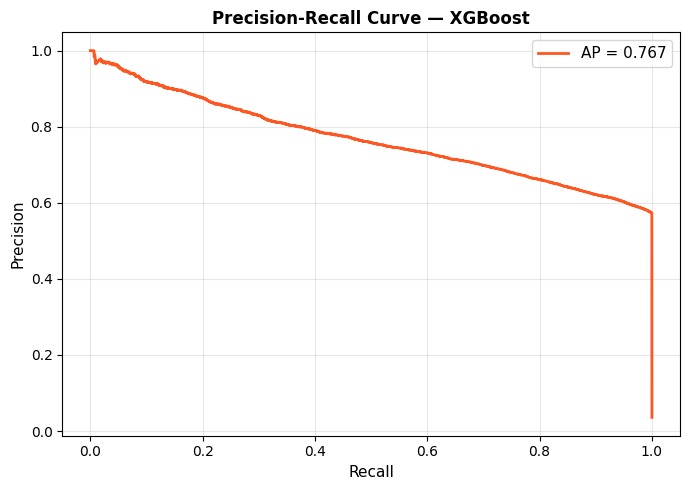

  Average Precision (AP) : 0.7667


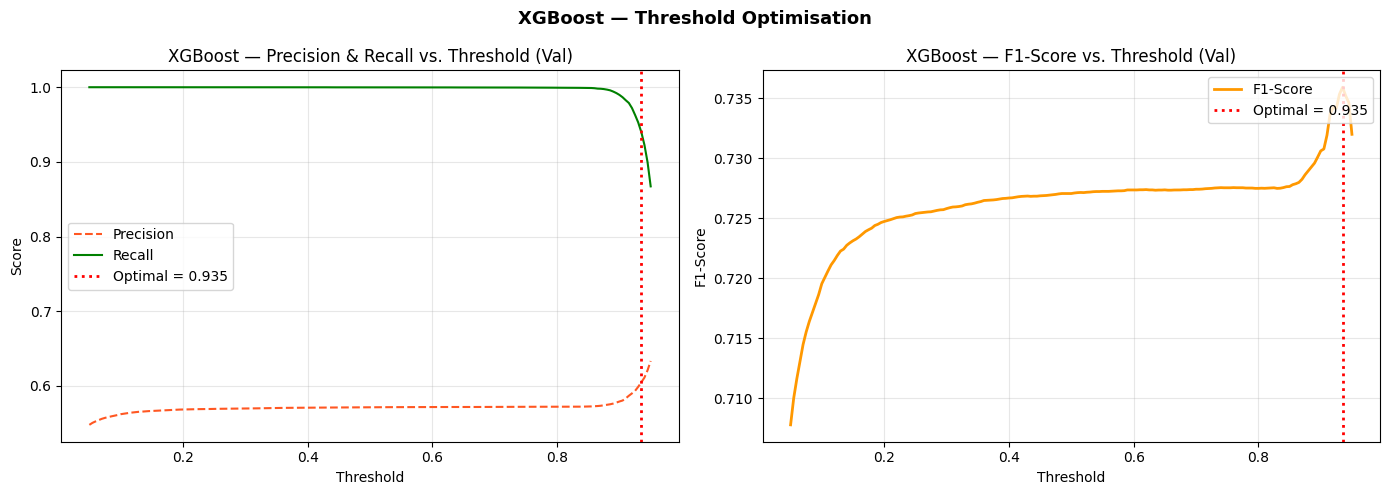

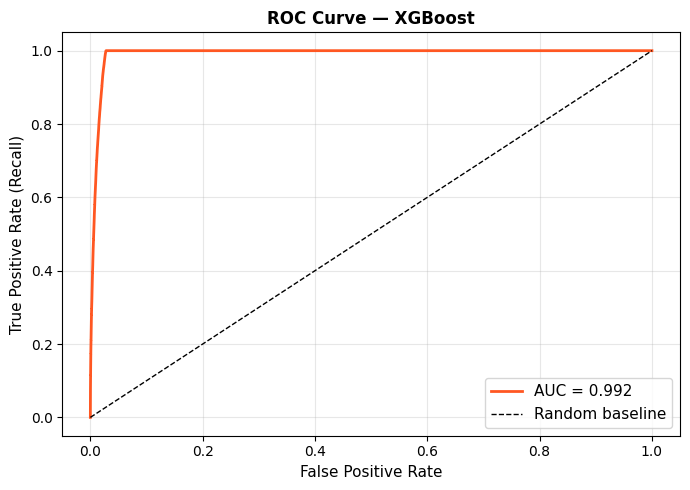

  ROC-AUC : 0.9918


In [ ]:
print("\n" + "=" * 70)
print("  MODEL 2 — XGBoost")
print("=" * 70)
xgb_spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators      = 700,
    objective         = "binary:logistic",
    tree_method       = "hist",
    max_depth         = 7,
    learning_rate     = 0.02,
    subsample         = 0.75,
    colsample_bytree  = 0.70,
    min_child_weight  = 20,
    gamma             = 0.5,
    reg_lambda        = 5.0,
    reg_alpha         = 3.0,
    scale_pos_weight  = xgb_spw,
    eval_metric       = "aucpr",
    device            = _DEVICE_XGB,
    n_jobs            = -1,
    verbosity         = 1,
    random_state      = RANDOM_SEED,
)
print("Training XGBoost ...")
xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 70,
)
print("Training complete.\n")
y_proba_xgb_val              = xgb_model.predict_proba(X_val)[:, 1]
best_thresh_xgb, best_f1_xgb = find_optimal_threshold(y_val, y_proba_xgb_val)
print(f"[ XGB ] Optimal threshold (val F1 = {best_f1_xgb:.4f}) : {best_thresh_xgb}")
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb  = (y_proba_xgb >= best_thresh_xgb).astype(int)

evaluate_model("XGBoost",          y_test, y_pred_xgb, y_proba_xgb,     best_thresh_xgb)
plot_confusion_matrix("XGBoost",          y_test, y_pred_xgb, cmap="Oranges")
plot_pr_curve("XGBoost",          y_test, y_proba_xgb)
plot_threshold_analysis(
    "XGBoost", y_val, y_proba_xgb_val, best_thresh_xgb, color="#FF5722"
)
plot_roc_curve("XGBoost",          y_test, y_proba_xgb)


3 - LightGBM


  MODEL 3 — LightGBM
Training LightGBM ...
[70]	valid_0's average_precision: 0.752
[140]	valid_0's average_precision: 0.755509
[210]	valid_0's average_precision: 0.759668
[280]	valid_0's average_precision: 0.761249
[350]	valid_0's average_precision: 0.762448
[420]	valid_0's average_precision: 0.762817
[490]	valid_0's average_precision: 0.762799
[560]	valid_0's average_precision: 0.762375
[630]	valid_0's average_precision: 0.762009
[700]	valid_0's average_precision: 0.761627
Training complete.

[ LGB ] Optimal threshold (val F1 = 0.7363) : 0.94

  MODEL     : LightGBM
  Threshold : 0.940
              precision    recall  f1-score   support

   Legit (0)       1.00      0.98      0.99    482044
   Fraud (1)       0.61      0.93      0.74     17956

    accuracy                           0.98    500000
   macro avg       0.81      0.95      0.86    500000
weighted avg       0.98      0.98      0.98    500000

  ROC-AUC            : 0.9919
  Avg Precision (AP) : 0.7674


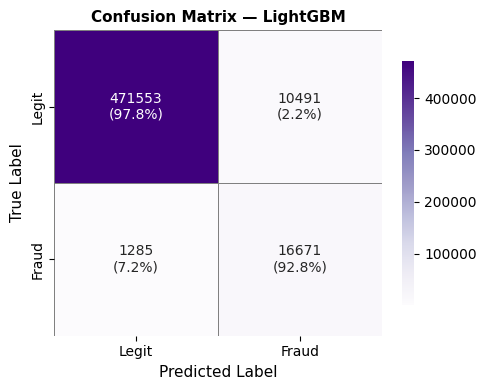

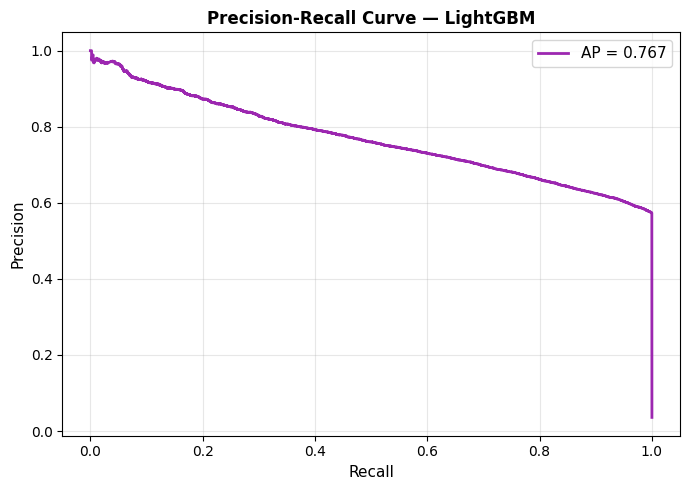

  Average Precision (AP) : 0.7674


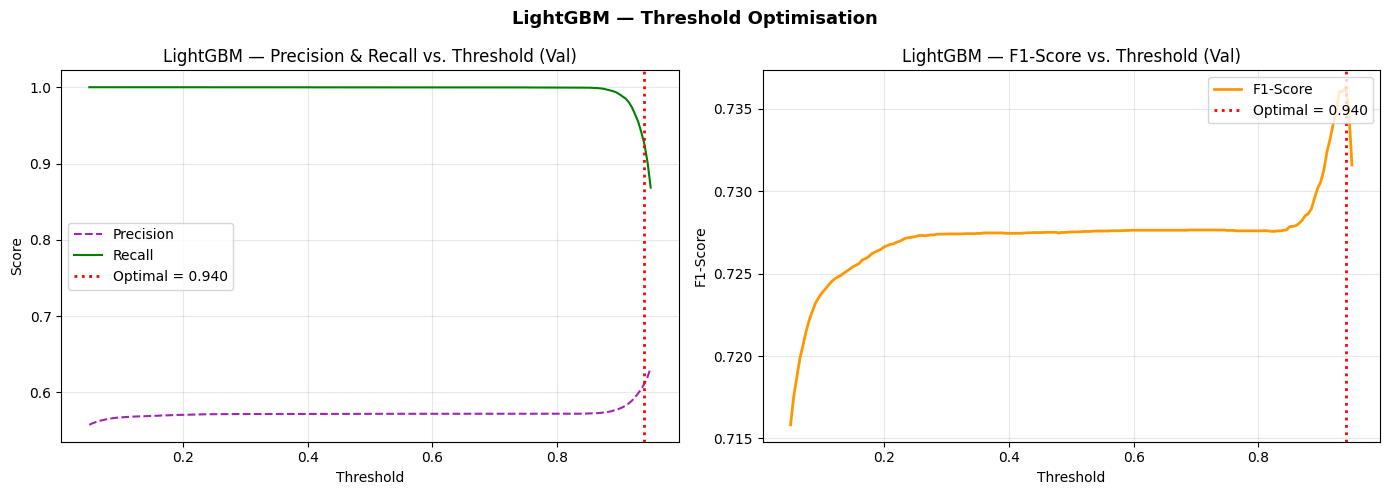

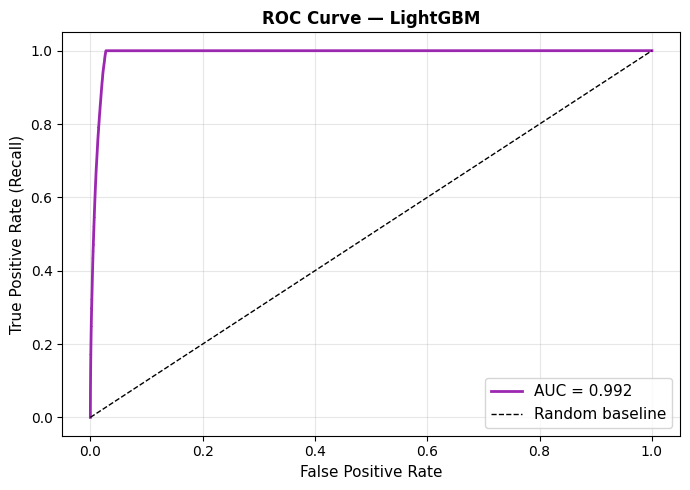

  ROC-AUC : 0.9919


In [ ]:
print("\n" + "=" * 70)
print("  MODEL 3 — LightGBM")
print("=" * 70)

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 700,
    num_leaves        = 63,
    max_depth         = 6,
    learning_rate     = 0.02,
    min_child_samples = 100,
    subsample         = 0.75,
    subsample_freq    = 1,
    colsample_bytree  = 0.70,
    reg_alpha         = 3.0,
    reg_lambda        = 5.0,
    scale_pos_weight  = xgb_spw,
    objective         = "binary",
    metric            = "average_precision",
    device            = _DEVICE_LGB,
    n_jobs            = -1,
    random_state      = RANDOM_SEED,
    verbose           = -1,
)
print("Training LightGBM ...")
lgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.log_evaluation(period=70),
    ],
)
print("Training complete.\n")
y_proba_lgb_val              = lgb_model.predict_proba(X_val)[:, 1]
best_thresh_lgb, best_f1_lgb = find_optimal_threshold(y_val, y_proba_lgb_val)
print(f"[ LGB ] Optimal threshold (val F1 = {best_f1_lgb:.4f}) : {best_thresh_lgb}")
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb  = (y_proba_lgb >= best_thresh_lgb).astype(int)

evaluate_model("LightGBM",         y_test, y_pred_lgb, y_proba_lgb,     best_thresh_lgb)
plot_confusion_matrix("LightGBM",         y_test, y_pred_lgb, cmap="Purples")
plot_pr_curve("LightGBM",         y_test, y_proba_lgb)
plot_threshold_analysis(
    "LightGBM", y_val, y_proba_lgb_val, best_thresh_lgb, color="#9C27B0"
)
plot_roc_curve("LightGBM",         y_test, y_proba_lgb)


4 — TabNet


  MODEL 4 — TabNet  (Attentive Tabular Neural Network)
Training TabNet ...
epoch 0  | loss: 0.3378  | val_auc: 0.98361 |  0:00:22s
epoch 10 | loss: 0.08146 | val_auc: 0.9893  |  0:04:02s
epoch 20 | loss: 0.08008 | val_auc: 0.9899  |  0:07:39s
epoch 30 | loss: 0.07804 | val_auc: 0.9908  |  0:11:16s
epoch 40 | loss: 0.07748 | val_auc: 0.99078 |  0:14:55s
epoch 50 | loss: 0.07691 | val_auc: 0.99105 |  0:18:33s
epoch 60 | loss: 0.07645 | val_auc: 0.99107 |  0:22:15s
epoch 70 | loss: 0.07655 | val_auc: 0.99104 |  0:25:57s
epoch 80 | loss: 0.07637 | val_auc: 0.99112 |  0:29:37s
epoch 90 | loss: 0.0763  | val_auc: 0.9911  |  0:33:15s
epoch 100| loss: 0.07686 | val_auc: 0.99083 |  0:36:52s
epoch 110| loss: 0.07656 | val_auc: 0.99085 |  0:40:28s
epoch 120| loss: 0.07635 | val_auc: 0.99101 |  0:44:06s

Early stopping occurred at epoch 124 with best_epoch = 94 and best_val_auc = 0.99122
Training complete.

[ TN ]  Optimal threshold (val F1 = 0.7282) : 0.82

  MODEL     : TabNet
  Threshold : 0.8

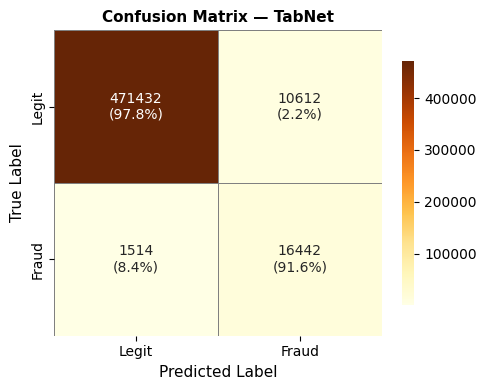

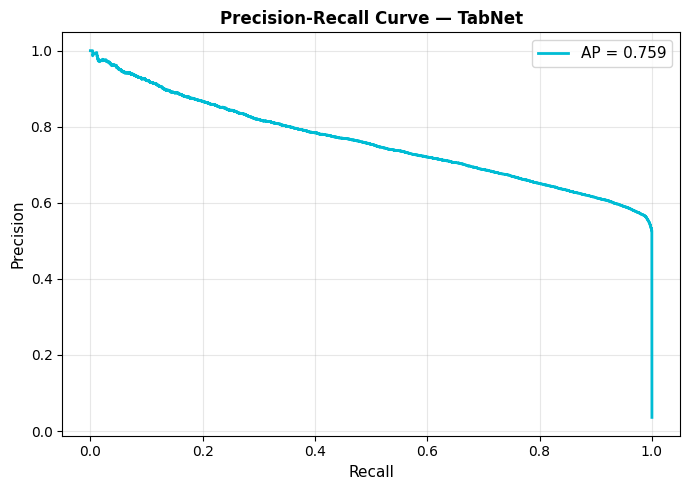

  Average Precision (AP) : 0.7593


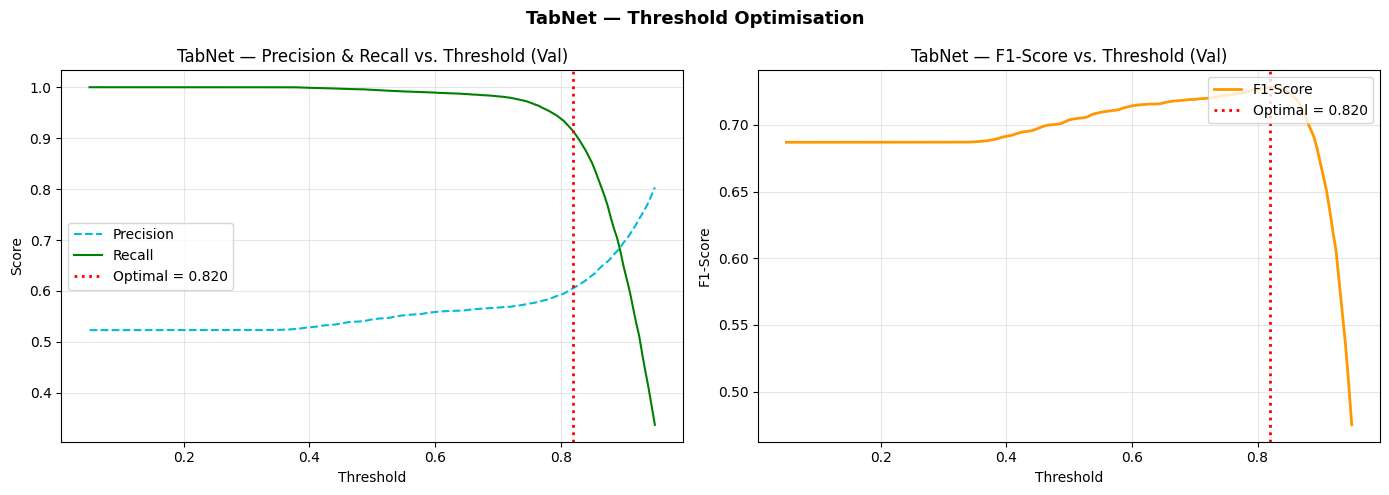

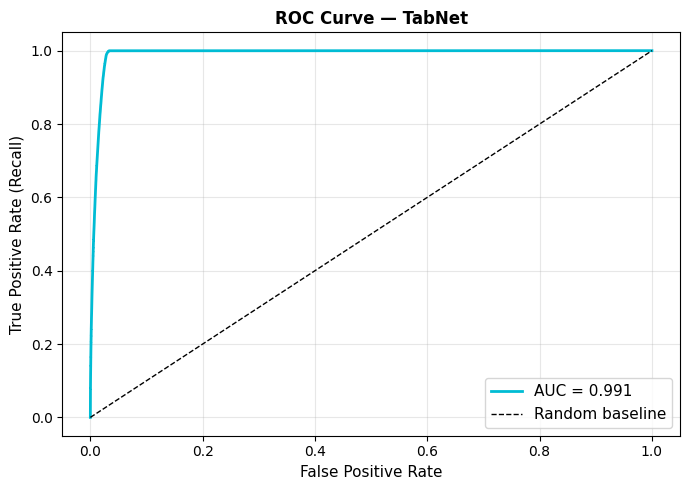

  ROC-AUC : 0.9914


In [ ]:
print("\n" + "=" * 70)
print("  MODEL 4 — TabNet ")
print("=" * 70)
X_train_tn = X_train.values.astype(np.float32)
X_val_tn   = X_val.values.astype(np.float32)
X_test_tn  = X_test.values.astype(np.float32)
y_train_tn = y_train.values.astype(int)
y_val_tn   = y_val.values.astype(int)
y_test_tn  = y_test.values.astype(int)
tabnet_model = TabNetClassifier(
    n_d              = 32,
    n_a              = 32,
    n_steps          = 5,
    gamma            = 1.3,
    n_independent    = 2,
    n_shared         = 2,
    momentum         = 0.02,
    lambda_sparse    = 1e-3,
    optimizer_fn     = torch.optim.Adam,
    optimizer_params = dict(lr=2e-3, weight_decay=1e-5),
    scheduler_fn     = torch.optim.lr_scheduler.StepLR,
    scheduler_params = {"step_size": 50, "gamma": 0.9},
    device_name      = _DEVICE_TN,
    verbose          = 10,
    seed             = RANDOM_SEED,
)
print("Training TabNet ...")
tabnet_model.fit(
    X_train_tn, y_train_tn,
    eval_set           = [(X_val_tn, y_val_tn)],
    eval_name          = ["val"],
    eval_metric        = ["auc"],
    max_epochs         = 150,
    patience           = 30,
    batch_size         = 4096,
    virtual_batch_size = 256,
)
print("Training complete.\n")
y_proba_tn_val             = tabnet_model.predict_proba(X_val_tn)[:, 1]
best_thresh_tn, best_f1_tn = find_optimal_threshold(y_val, y_proba_tn_val)
print(f"[ TN ]  Optimal threshold (val F1 = {best_f1_tn:.4f}) : {best_thresh_tn}")

y_proba_tn = tabnet_model.predict_proba(X_test_tn)[:, 1]
y_pred_tn  = (y_proba_tn >= best_thresh_tn).astype(int)

evaluate_model("TabNet", y_test, y_pred_tn, y_proba_tn, best_thresh_tn)
plot_confusion_matrix("TabNet", y_test, y_pred_tn, cmap="YlOrBr")
plot_pr_curve("TabNet", y_test, y_proba_tn)
plot_threshold_analysis(
    "TabNet", y_val, y_proba_tn_val, best_thresh_tn, color="#00BCD4"
)
plot_roc_curve("TabNet", y_test, y_proba_tn)


Confusion Matrix


Confusion Matrices All Models


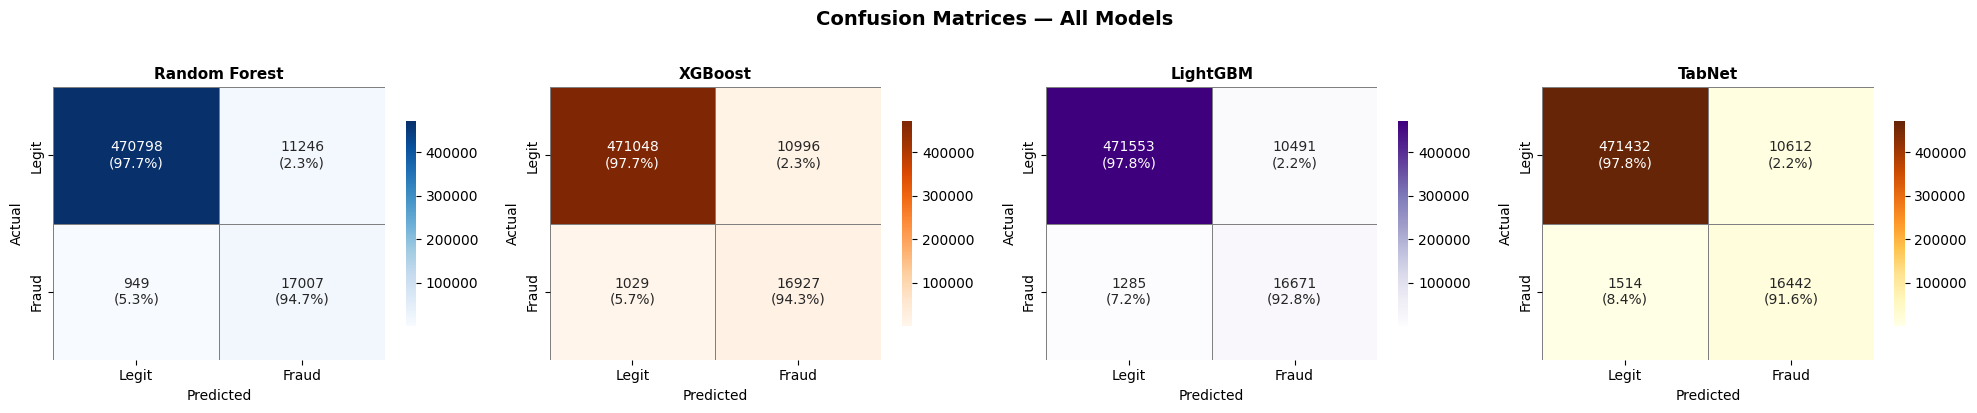

In [ ]:
print("\n" + "=" * 70)
print("Confusion Matrices All Models")
print("=" * 70)
_model_names = list(cm_data.keys())
_n           = len(_model_names)
fig, axes    = plt.subplots(1, _n, figsize=(5 * _n, 4))
if _n == 1:
    axes = [axes]
for ax, name in zip(axes, _model_names):
    cm   = cm_data[name]["cm"]
    cmap = cm_data[name]["cmap"]
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([
        [f"{v}\n({p:.1f}%)" for v, p in zip(rv, rp)]
        for rv, rp in zip(cm, cm_pct)
    ])
    sns.heatmap(
        cm, annot=labels, fmt="", cmap=cmap,
        xticklabels=["Legit", "Fraud"],
        yticklabels=["Legit", "Fraud"],
        ax=ax, linewidths=0.5, linecolor="gray",
        cbar_kws={"shrink": 0.75},
    )
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual",    fontsize=10)
    ax.set_title(name, fontsize=11, fontweight="bold")
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "confusion_matrices_all.png"), dpi=150, bbox_inches="tight"
)
plt.show()

Precision-Recall Curves


Precision-Recall Curves All Models


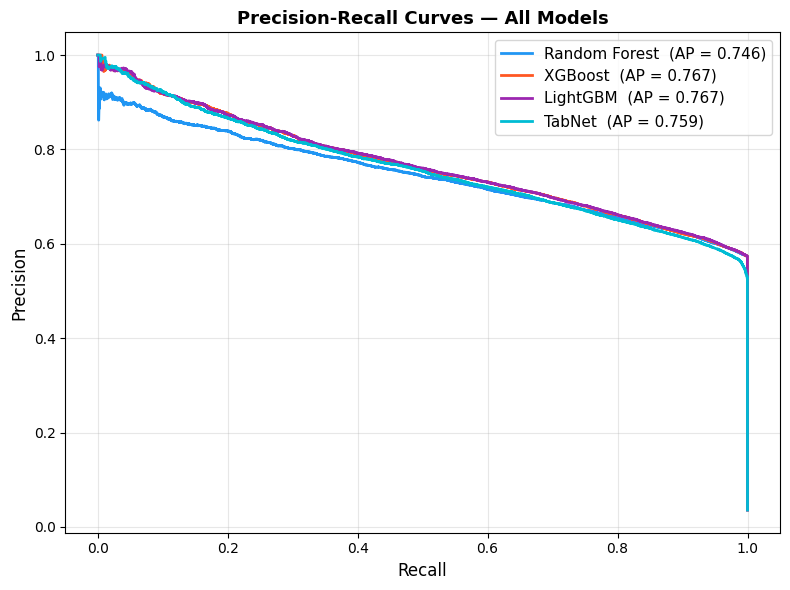

In [ ]:
print("\n" + "=" * 70)
print("Precision-Recall Curves All Models")
print("=" * 70)
plt.figure(figsize=(8, 6))
for name, data in pr_data.items():
    plt.plot(
        data["recall"], data["precision"],
        color=data["color"], lw=2,
        label=f"{name}  (AP = {data['ap']:.3f})",
    )
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curves — All Models", fontsize=13, fontweight="bold")
plt.legend(loc="upper right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "pr_curves_all_models.png"), dpi=150, bbox_inches="tight"
)
plt.show()

ROC Curves


ROC Curves All Models


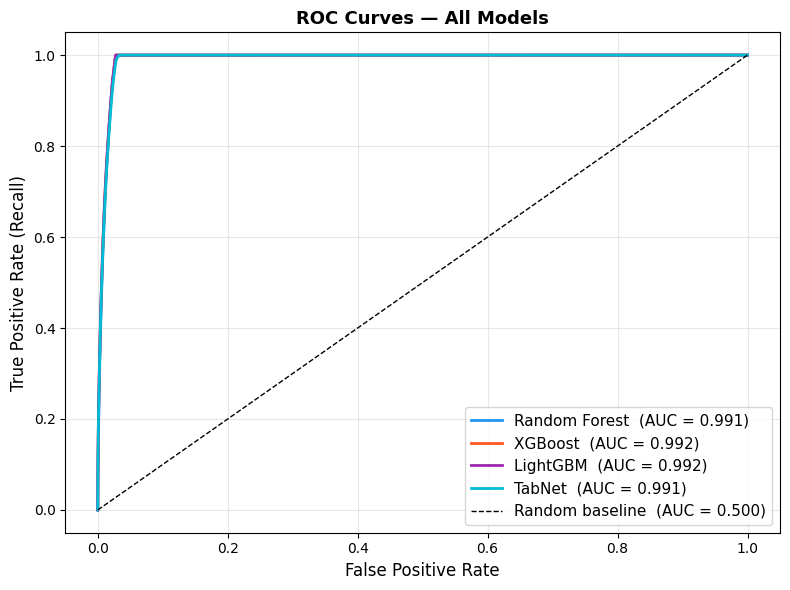

In [ ]:
print("\n" + "=" * 70)
print("ROC Curves All Models")
print("=" * 70)
plt.figure(figsize=(8, 6))
for name, data in roc_data.items():
    plt.plot(
        data["fpr"], data["tpr"],
        color=data["color"], lw=2,
        label=f"{name}  (AUC = {data['auc']:.3f})",
    )
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline  (AUC = 0.500)")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "roc_curves_all_models.png"), dpi=150, bbox_inches="tight"
)
plt.show()

Feature Importance


Feature Importance


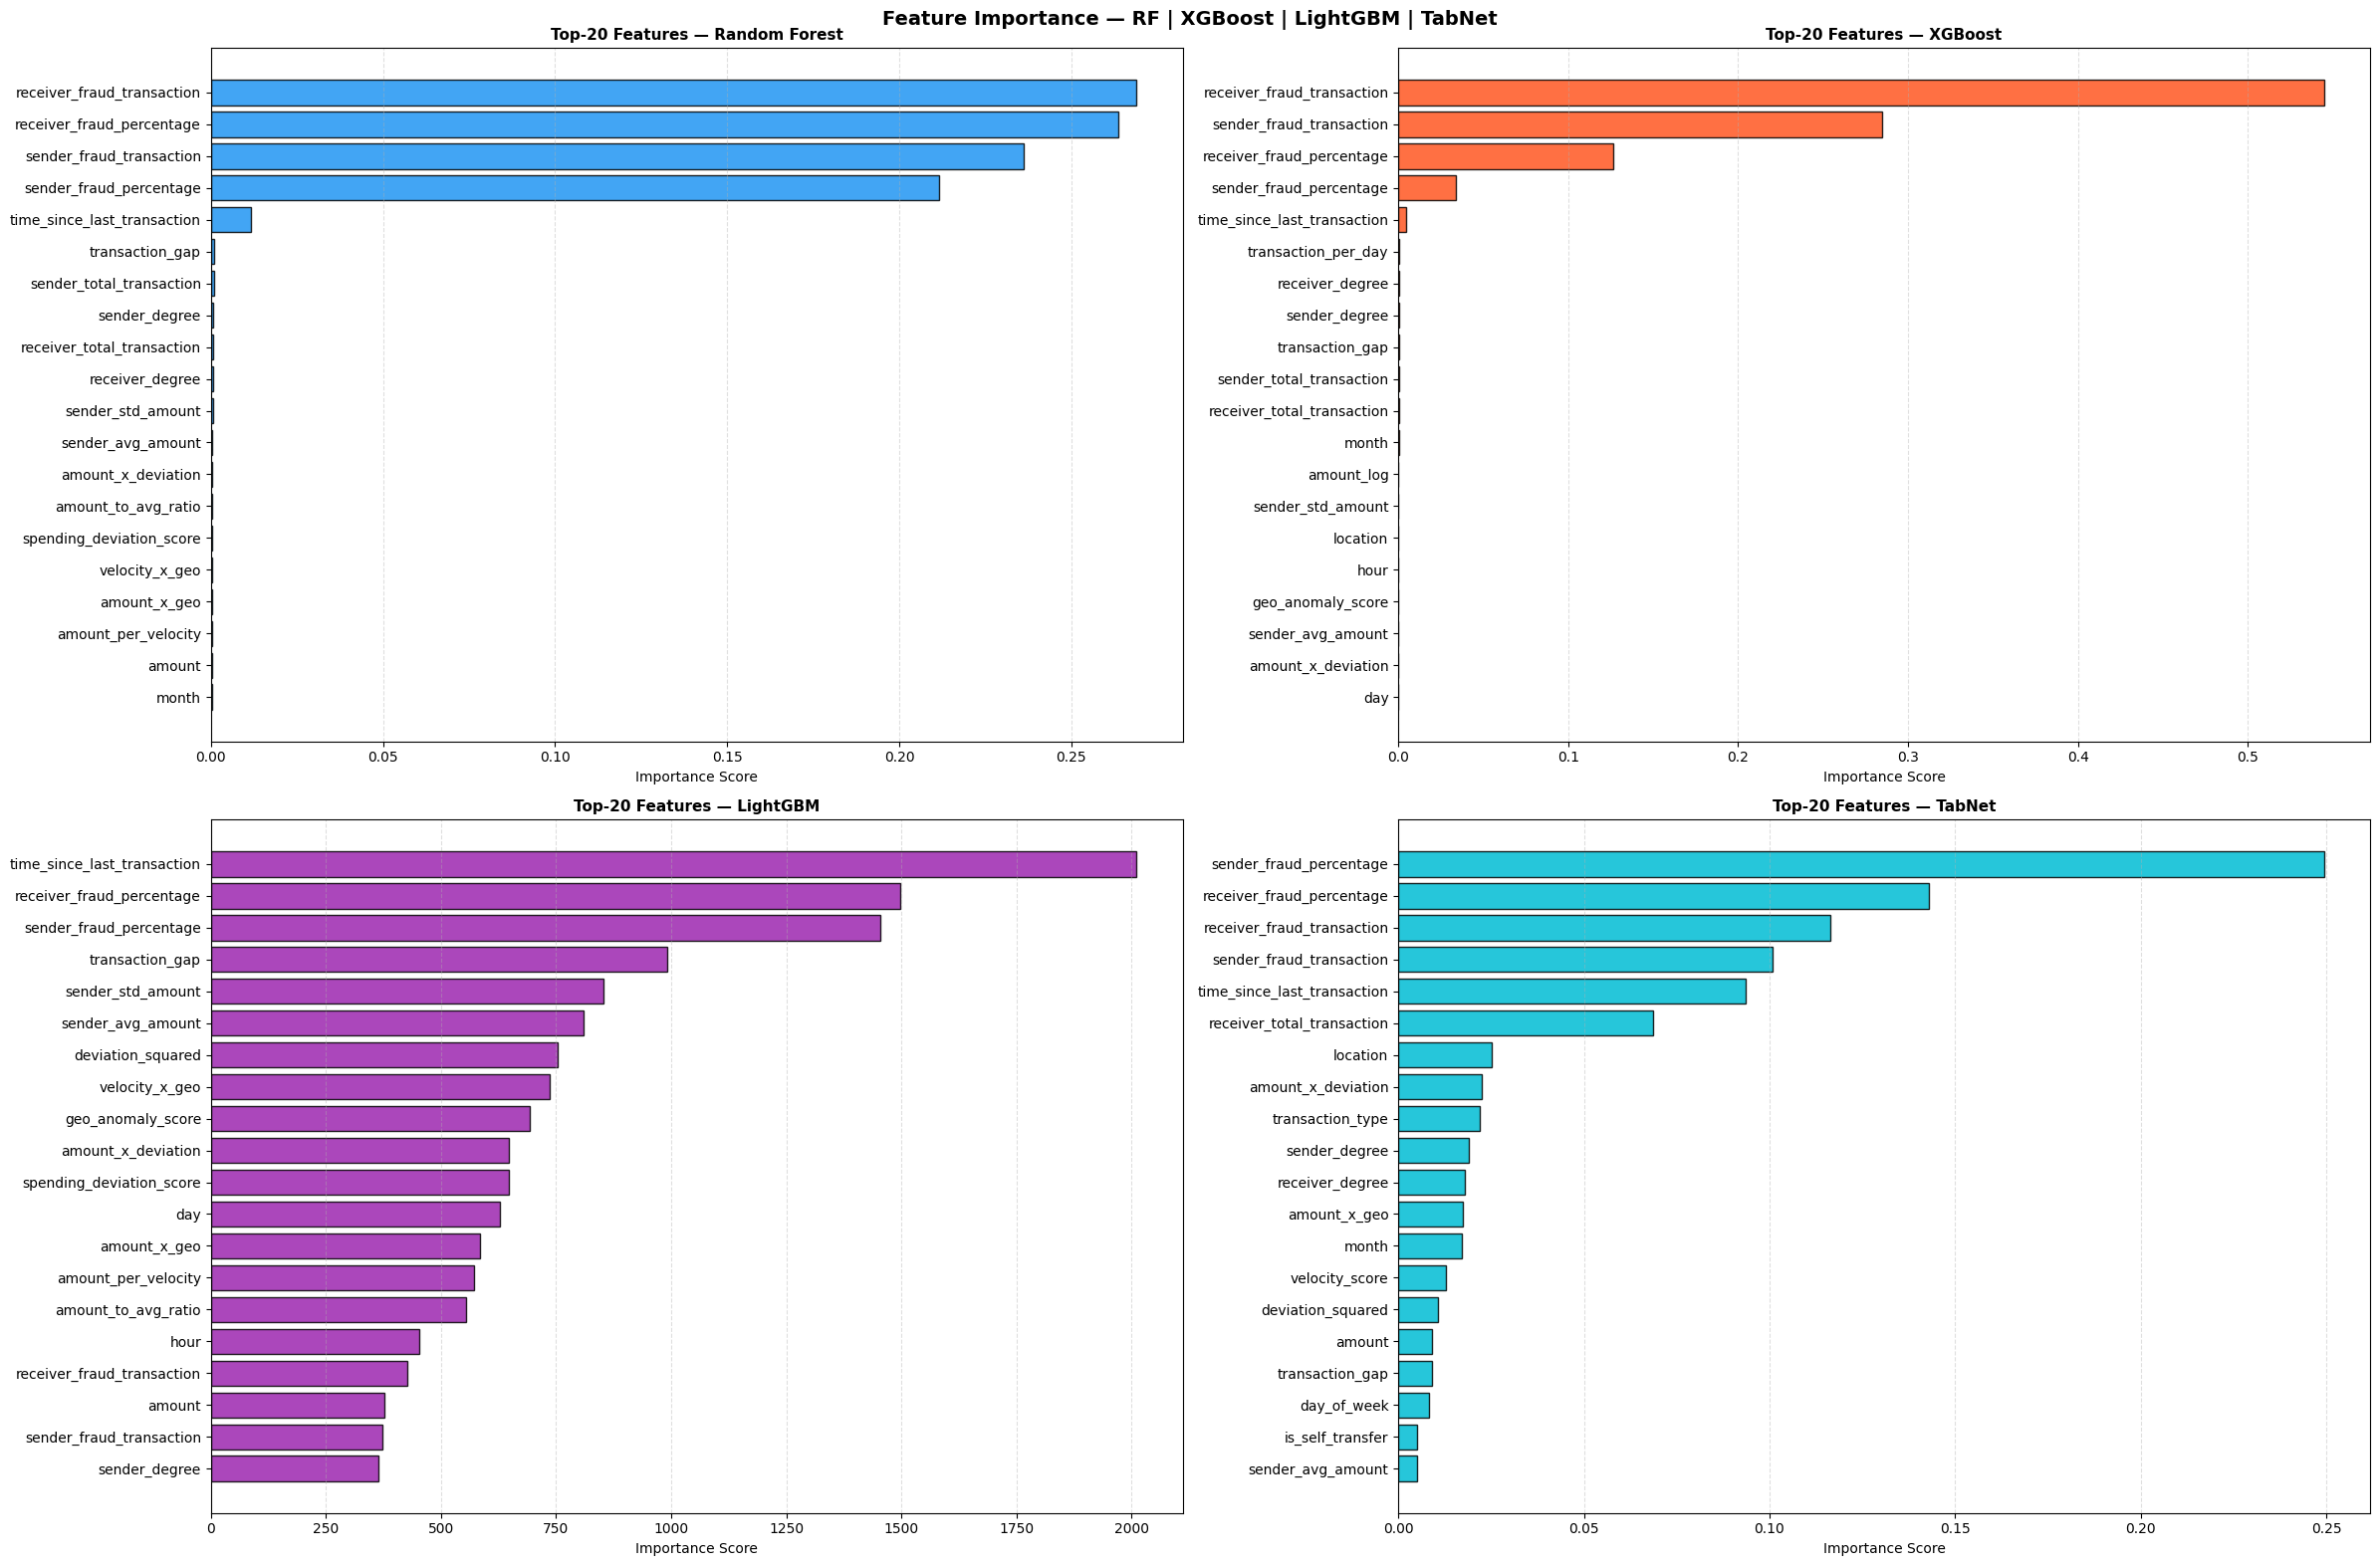

In [ ]:
print("\n" + "=" * 70)
print("Feature Importance")
print("=" * 70)

importances = {
    "Random Forest" : rf_model.feature_importances_,
    "XGBoost"       : xgb_model.feature_importances_,
    "LightGBM"      : lgb_model.feature_importances_,
    "TabNet"        : tabnet_model.feature_importances_,
}
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
axes_flat = axes.flatten()
for ax, (model_name, imp) in zip(axes_flat, importances.items()):
    idx   = np.argsort(imp)[::-1][:20]
    color = MODEL_COLORS[model_name]
    ax.barh(
        [FEATURE_NAMES[i] for i in idx[::-1]],
        imp[idx[::-1]],
        color=color, alpha=0.85, edgecolor="black",
    )
    ax.set_title(f"Top-20 Features — {model_name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Importance Score", fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle(
    "Feature Importance — RF | XGBoost | LightGBM | TabNet",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "feature_importance_all.png"), dpi=150, bbox_inches="tight"
)
plt.show()


Save Trained Models & Preprocessors

In [ ]:
print("\n" + "=" * 70)
print("Saving Trained Models & Preprocessors")
print("=" * 70)

# Random Forest → joblib
rf_path = os.path.join(MODELS_DIR, "random_forest.pkl")
joblib.dump(rf_model, rf_path)
print(f"  Random Forest      → {rf_path}  "
      f"({os.path.getsize(rf_path)/1024/1024:.1f} MB)")

# XGBoost → native JSON (cross-platform, version-stable)
xgb_path = os.path.join(MODELS_DIR, "xgboost.json")
xgb_model.save_model(xgb_path)
print(f"  XGBoost            → {xgb_path}  "
      f"({os.path.getsize(xgb_path)/1024/1024:.1f} MB)")

# LightGBM → native .txt
lgb_path = os.path.join(MODELS_DIR, "lightgbm.txt")
lgb_model.booster_.save_model(lgb_path)
print(f"  LightGBM           → {lgb_path}  "
      f"({os.path.getsize(lgb_path)/1024/1024:.1f} MB)")

# TabNet → native save (.zip created automatically by pytorch-tabnet)
tn_path = os.path.join(MODELS_DIR, "tabnet")
tabnet_model.save_model(tn_path)
print(f"  TabNet             → {tn_path}.zip  "
      f"({os.path.getsize(tn_path + '.zip')/1024/1024:.1f} MB)")

# Imputer → joblib (needed for new data preprocessing)
imp_path = os.path.join(MODELS_DIR, "imputer.pkl")
joblib.dump(imputer, imp_path)
print(f"  Imputer            → {imp_path}")

# Label Encoders → joblib dict
le_path = os.path.join(MODELS_DIR, "label_encoders.pkl")
joblib.dump(label_encoders, le_path)
print(f"  Label Encoders     → {le_path}")

# Threshold values for all models → JSON
thresholds_path = os.path.join(MODELS_DIR, "thresholds.json")
with open(thresholds_path, "w") as f:
    json.dump({
        "Random Forest" : best_thresh_rf,
        "XGBoost"       : best_thresh_xgb,
        "LightGBM"      : best_thresh_lgb,
        "TabNet"        : best_thresh_tn,
    }, f, indent=2)
print(f"  Thresholds         → {thresholds_path}")

# Feature names → JSON (required to align columns during inference)
fn_path = os.path.join(MODELS_DIR, "feature_names.json")
with open(fn_path, "w") as f:
    json.dump(FEATURE_NAMES, f, indent=2)
print(f"  Feature names      → {fn_path}")

# Categorical columns list → JSON (needed to re-apply LabelEncoder in order)
cat_cols_path = os.path.join(MODELS_DIR, "cat_cols.json")
with open(cat_cols_path, "w") as f:
    json.dump(cat_cols, f, indent=2)
print(f"  Categorical cols   → {cat_cols_path}")



Saving Trained Models & Preprocessors
  Random Forest      → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/random_forest.pkl  (77.1 MB)
  XGBoost            → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/xgboost.json  (2.9 MB)
  LightGBM           → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/lightgbm.txt  (2.0 MB)
Successfully saved model at /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/tabnet.zip
  TabNet             → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/tabnet.zip  (0.5 MB)
  Imputer            → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/imputer.pkl
  Label Encoders     → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/label_encoders.pkl
  Thresholds         → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/thresholds.json
  Feature names      → /content/drive/MyDrive/Colab_Notebooks/trained_models_un3/feature_names.json
  Categorical cols   → /content/drive/MyDrive/Colab_No

Results Summary & Best Model Selection


Final Comparison & Best Model Selection

Model                   Accuracy  Precision   Recall       F1   ROC-AUC        AP  Threshold
------------------------------------------------------------------------------------------
Random Forest             0.9756     0.6020   0.9471   0.7361    0.9915    0.7456      0.920
XGBoost                   0.9759     0.6062   0.9427   0.7379    0.9918    0.7667      0.935
LightGBM                  0.9764     0.6138   0.9284   0.7390    0.9919    0.7674      0.940
TabNet                    0.9757     0.6077   0.9157   0.7306    0.9914    0.7593      0.820
------------------------------------------------------------------------------------------

  ★ BEST MODEL (by F1-Score) : LightGBM
    Threshold (optimised)    : 0.940
    Accuracy                 : 0.9764
    Precision                : 0.6138
    Recall                   : 0.9284
    F1-Score                 : 0.7390
    ROC-AUC                  : 0.9919
    AP (AUCPR)               : 0.7674


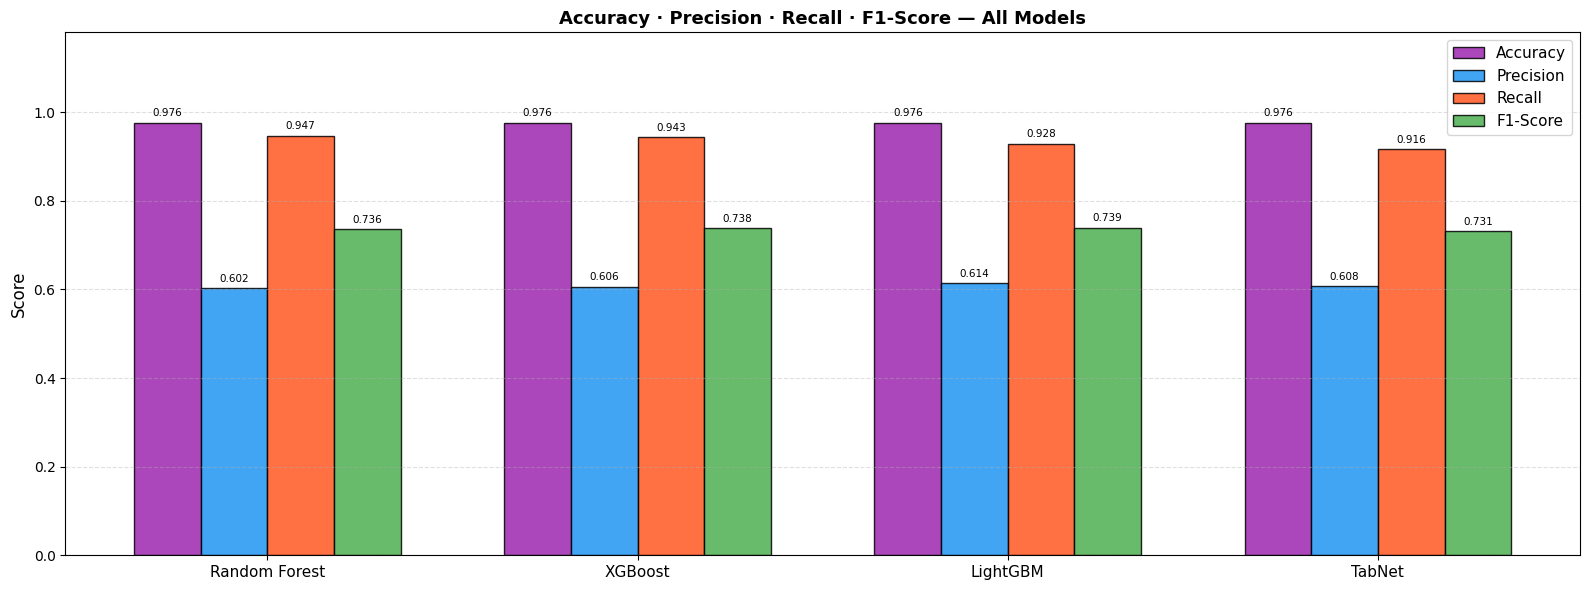

In [ ]:
print("\n" + "=" * 70)
print("Final Comparison & Best Model Selection")
print("=" * 70)

results_df  = pd.DataFrame(results).T
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "AP (AUCPR)"]

print(f"\n{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'ROC-AUC':>9} {'AP':>9} {'Threshold':>10}")
print("-" * 90)
for model_name, row in results_df[metric_cols + ["Threshold"]].iterrows():
    print(
        f"{model_name:<22} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} "
        f"{row['Recall']:>8.4f} {row['F1-Score']:>8.4f} "
        f"{row['ROC-AUC']:>9.4f} {row['AP (AUCPR)']:>9.4f} {row['Threshold']:>10.3f}"
    )
print("-" * 90)

best_model_name = results_df["F1-Score"].idxmax()
print(f"\n  ★ BEST MODEL (by F1-Score) : {best_model_name}")
print(f"    Threshold (optimised)    : {results_df.loc[best_model_name,'Threshold']:.3f}")
print(f"    Accuracy                 : {results_df.loc[best_model_name,'Accuracy']:.4f}")
print(f"    Precision                : {results_df.loc[best_model_name,'Precision']:.4f}")
print(f"    Recall                   : {results_df.loc[best_model_name,'Recall']:.4f}")
print(f"    F1-Score                 : {results_df.loc[best_model_name,'F1-Score']:.4f}")
print(f"    ROC-AUC                  : {results_df.loc[best_model_name,'ROC-AUC']:.4f}")
print(f"    AP (AUCPR)               : {results_df.loc[best_model_name,'AP (AUCPR)']:.4f}")

# Grouped bar chart — all metrics × all models
_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
_colors  = ["#9C27B0", "#2196F3", "#FF5722", "#4CAF50"]
_x       = np.arange(len(results_df))
_width   = 0.18

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(_metrics, _colors)):
    bars = ax.bar(
        _x + i * _width, results_df[metric], _width,
        label=metric, color=color, edgecolor="black", alpha=0.85,
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.010,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7.5,
        )
ax.set_xticks(_x + _width * (len(_metrics) - 1) / 2)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Accuracy · Precision · Recall · F1-Score — All Models",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "comparison_all_models.png"), dpi=150, bbox_inches="tight"
)
plt.show()

# Save best model name to JSON for deployment reference
with open(os.path.join(MODELS_DIR, "best_model.json"), "w") as f:
    json.dump({"best_model": best_model_name,
               "threshold": results_df.loc[best_model_name, "Threshold"]}, f, indent=2)

FINAL PIPELINE SUMMARY

In [ ]:
print("\n" + "=" * 70)
print("  PIPELINE COMPLETE")
print("=" * 70)
print(f"\n  Plots saved  : {PLOTS_DIR}/")
_png_files = sorted(f for f in os.listdir(PLOTS_DIR) if f.endswith(".png"))
for fname in _png_files:
    _kb = os.path.getsize(os.path.join(PLOTS_DIR, fname)) / 1024
    print(f"    {fname:<60}  {_kb:>7.1f} KB")

print(f"\n  Models saved : {MODELS_DIR}/")
for fname in sorted(os.listdir(MODELS_DIR)):
    _mb = os.path.getsize(os.path.join(MODELS_DIR, fname)) / 1024 / 1024
    print(f"    {fname:<45}  {_mb:>7.1f} MB")

print(f"\n  Best model          : {best_model_name}")
print(f"  F1-Score (test set) : {results_df.loc[best_model_name,'F1-Score']:.4f}")
print(f"  ROC-AUC (test set)  : {results_df.loc[best_model_name,'ROC-AUC']:.4f}")
print("=" * 70)


  PIPELINE COMPLETE

  Plots saved  : /content/drive/MyDrive/Colab_Notebooks/fraud_detection_plots_un3/
    01_class_distribution.png                                        39.2 KB
    02_fraud_by_month.png                                            42.1 KB
    03_transaction_type.png                                          44.6 KB
    04_behavioural_features.png                                     194.9 KB
    05_amount_distribution.png                                       63.1 KB
    06_correlation_matrix_raw.png                                    87.1 KB
    07_correlation_matrix_engineered.png                            322.5 KB
    cm_LightGBM.png                                                  42.0 KB
    cm_Random_Forest.png                                             42.8 KB
    cm_TabNet.png                                                    41.4 KB
    cm_XGBoost.png                                                   42.8 KB
    comparison_all_models.png                   